# Модели семейства ARIMA для предсказания стоимости акций

ARIMA модели - семейство моделей анализа временных рядов. Модель SARIMAX даже позволяет добавить внешние признаки, например, цены других акций, или стоимость индекса мосбиржи.

SARIMAX состоит из нескольких частей:
- **S** - сезонность
- **AR** - авторегрессия (зависимость текущего значения от предыдущих значений ряда)
- **I** - интегрирование (дифференцируем ряд, чтобы сделать его стационарным)
- **MA** - скользящее среднее (зависимость текущего значения от прошлых ошибок модели)
- **X** - eXogenous variables (внешние факторы)

## Функции

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.auto import tqdm


def train_test_split_by_date(df, date_column='begin', target_column='close', test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values(date_column).reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df[date_column].min()} - {train_df[date_column].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df[date_column].min()} - {test_df[date_column].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=[date_column, target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=[date_column, target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

def visualize_predictions_comparison(
    results_df, title, y_label, date_column='begin', target_column='close', predict_column='predict',):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame
        title: str, заголовок графика
        y_label: str, название оси Y
        date_column: str, название столбца с датой
        target_column: str, название столбца с target значениями
        predict_column: str, название столбца с предсказанными значениями
    """
    # Конвертируем дату если нужно
    if results_df[date_column].dtype == 'object':
        results_df = results_df.copy()
        results_df[date_column] = pd.to_datetime(results_df[date_column])
    
    # Сортируем по дате
    results_df = results_df.sort_values(date_column)
    
    fig = go.Figure()

    # Target
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[target_column],
            mode="lines+markers",
            name="target",
            line=dict(width=3, color="#2E8B57"),
            marker=dict(symbol="circle", size=6),
            opacity=0.8
        )
    )

    # Prediction
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[predict_column],
            mode="lines+markers",
            name="prediction",
            line=dict(width=3, color="#DC143C"),
            marker=dict(symbol="square", size=6),
            opacity=0.8
        )
    )

    # Нулевая линия
    fig.add_hline(
        y=0,
        line_width=1,
        line_dash="solid",
        line_color="black",
        opacity=0.5
    )

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(size=18)
        ),
        xaxis_title="Дата",
        yaxis_title=y_label,
        template="plotly_white",
        width=1200,
        height=600,
        hovermode="x unified"
    )

    fig.update_xaxes(
        tickangle=45,
        showgrid=True
    )

    fig.update_yaxes(
        showgrid=True
    )

    fig.show()

def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "direction_accuracy": direction_accuracy,
    }

def add_target_after_time_delta(df, time_delta, date_column='begin', price_column='close', target_date_column='target_date', target_price_column='target'):
    """Добавляет столбец с целевой переменной - изменением цены через time_delta дней"""
    df = df.copy()
    df[target_price_column] = df[price_column].shift(-time_delta)
    df[target_date_column] = df[date_column].shift(-time_delta)
    return df

In [2]:
def log_return(series, periods=1):
    return np.log(series / series.shift(periods))


def inverse_log_return(log_ret, prev_price):
    return prev_price * np.exp(log_ret)

In [3]:
def _test_log_return():
    prices = pd.Series([100.0, 110.0, 121.0])
    log_ret = log_return(prices)
    log_ret_reversed = inverse_log_return(log_ret, prices.shift(1))
    assert np.allclose(prices[1:], log_ret_reversed[1:], rtol=1e-6)

_test_log_return()

In [4]:
def forward_log_return(series, periods: int = 1):
    """Лог-доходность на periods дней вперед"""
    return np.log(series.shift(-periods) / series)


def restore_current_price(log_ret, future_price):
    """Обратная функция лог-доходности: возвращает значение на основе будущего значения"""
    return future_price / np.exp(log_ret)

In [5]:
restore_current_price(forward_log_return(pd.Series([100.0, 110.0, 121.0])), pd.Series([110.0, 121.0, None]))

0    100.0
1    110.0
2      NaN
dtype: float64

In [6]:
def _test_forward_log_return():
    prices = pd.Series([100.0, 110.0, 121.0])
    log_ret = forward_log_return(prices)
    log_ret_reversed = restore_current_price(log_ret, prices.shift(-1))
    display(prices)
    display(log_ret_reversed)
    assert np.allclose(prices[:-1], log_ret_reversed[:-1], rtol=1e-6)

_test_forward_log_return()

0    100.0
1    110.0
2    121.0
dtype: float64

0    100.0
1    110.0
2      NaN
dtype: float64

## 1. Загрузка и исследование данных

### 1.1. Загружаем данные

In [7]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))
sys.path

['/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python312.zip',
 '/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python3.12',
 '/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python3.12/lib-dynload',
 '',
 '/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages',
 '/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor']

In [8]:
from datetime import datetime

date_start = datetime(2022, 5, 1)

In [9]:
from app.core.clients.moex import Boards, Engines, Interval, Markets, MOEXClient

moex_client = MOEXClient()
stocks_data = await moex_client.get_data(
    tickers=['GAZP', 'LKOH', 'ROSN', 'SBER'],
    engine=Engines.STOCK,
    market=Markets.SHARES,
    board=Boards.TQBR,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)

In [10]:
stocks_data.keys()

dict_keys(['GAZP', 'LKOH', 'ROSN', 'SBER'])

In [11]:
stocks_data['GAZP'].describe()

,open,close,high,low,value,volume,begin,end
count,16676.000000,16676.000000,16676.000000,16676.000000,1.667600e+04,1.667600e+04,16676,16676
mean,150.880732,150.861837,151.294554,150.418754,4.801111e+08,3.206465e+06,2024-07-18 09:02:49.680978432,2024-07-18 10:02:38.661129472
min,105.620000,105.650000,105.850000,105.220000,3.017040e+04,2.600000e+02,2022-05-04 09:00:00,2022-05-04 09:59:59
25%,126.900000,126.890000,127.240000,126.550000,1.009755e+08,6.927800e+05,2023-07-21 22:45:00,2023-07-21 23:44:58.249999872
50%,141.860000,141.850000,142.290000,141.240000,2.465683e+08,1.643265e+06,2024-08-22 22:30:00,2024-08-22 23:29:57
75%,166.920000,166.910000,167.290000,166.530000,5.509027e+08,3.769895e+06,2025-07-23 13:15:00,2025-07-23 14:14:59
max,320.800000,320.800000,322.990000,319.590000,2.385369e+10,1.410863e+08,2026-05-05 19:00:00,2026-05-05 19:46:42
std,31.995064,31.976660,32.144548,31.813097,8.448380e+08,5.206977e+06,NaN,NaN


In [12]:
stocks_data['GAZP'].head()

,open,close,high,low,value,volume,begin,end,ticker
0,241.00,241.00,241.00,241.00,1.779544e+07,73840,2022-05-04 09:00:00,2022-05-04 09:59:59,GAZP
1,241.01,238.90,244.39,238.00,1.687852e+09,7012280,2022-05-04 10:00:00,2022-05-04 10:59:59,GAZP
2,238.95,233.80,240.20,233.50,1.187417e+09,5025080,2022-05-04 11:00:00,2022-05-04 11:59:59,GAZP
3,233.71,235.63,236.30,233.17,5.070772e+08,2159900,2022-05-04 12:00:00,2022-05-04 12:59:59,GAZP
4,235.63,234.61,235.84,233.90,3.604205e+08,1535620,2022-05-04 13:00:00,2022-05-04 13:59:59,GAZP


### 1.2. Обработка данных

In [13]:
# Возьмем только основную сессию

stocks_data_main_session = {}

for ticker, df in stocks_data.items():
    df = df.copy()
    df['hour'] = df['begin'].dt.hour
    # Основная сессия на Мосбирже: с 9:50 по 18:50.
    stocks_data_main_session[ticker] = df[df['hour'].between(10, 18)].drop(columns='hour')
    # Уберем выходные дни
    stocks_data_main_session[ticker] = stocks_data_main_session[ticker][stocks_data_main_session[ticker]['begin'].dt.dayofweek < 5]

stocks_data_main_session['GAZP'].shape

(9132, 9)

In [14]:
# Посмотрим на данные

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=stocks_data['GAZP']["begin"],
        y=stocks_data['GAZP']["close"],
        mode="lines",
        name="Close price"
    )
)

fig.update_layout(
    title="GAZP",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

### 1.3. Анализ цены акций

Пока попробуем проанализировать цены акций "в лоб" для бэйзлайна

In [15]:
# # Добавим разные таргеты:
# # - цена через час
# # - цена через день
# # - цена через неделю

# stocks_data_1h = {}
# stocks_data_1d = {}
# stocks_data_1w = {}

# for ticker, df in stocks_data.items():
#     stocks_data_1h[ticker] = add_target_after_time_delta(df, time_delta=1, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1d[ticker] = add_target_after_time_delta(df, time_delta=24, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1w[ticker] = add_target_after_time_delta(df, time_delta=24*7, date_column='begin', price_column='close', target_price_column='target')

# display(stocks_data_1h['GAZP'].head())
# stocks_data_1h['GAZP'].shape

In [16]:
# Сгруппируем по дням.

stocks_data_daily = {}
for ticker, df in stocks_data_main_session.items():
    stocks_data_daily[ticker] = df.resample('D', on='begin').last().dropna().reset_index()

display(stocks_data_daily['GAZP'].head())
stocks_data_daily['GAZP'].shape

,begin,open,close,high,low,value,volume,end,ticker
0,2022-05-04,234.25,234.16,234.80,234.16,249223456.1,1063310.0,2022-05-04 18:59:59,GAZP
1,2022-05-05,238.31,238.60,238.74,238.29,263457477.8,1104440.0,2022-05-05 18:59:59,GAZP
2,2022-05-06,240.04,240.10,240.65,239.98,367885098.9,1532000.0,2022-05-06 18:59:59,GAZP
3,2022-05-11,241.84,241.99,242.41,241.51,271818862.6,1122700.0,2022-05-11 18:59:59,GAZP
4,2022-05-12,233.50,230.56,233.93,230.30,460096965.5,1982820.0,2022-05-12 18:59:59,GAZP


(1015, 9)

In [17]:
stocks_data_daily['GAZP'][stocks_data_daily['GAZP']['begin'].dt.year == 2025].count()

begin     253
open      253
close     253
high      253
low       253
value     253
volume    253
end       253
ticker    253
dtype: int64

In [18]:
stocks_data_daily['GAZP'].tail(20)

,begin,open,close,high,low,value,volume,end,ticker
995,2026-04-08,130.74,130.80,131.14,130.70,4.397070e+08,3358600.0,2026-04-08 18:59:07,GAZP
996,2026-04-09,128.71,128.53,128.82,128.38,7.584608e+08,5896330.0,2026-04-09 18:59:59,GAZP
997,2026-04-10,128.54,128.62,129.26,128.32,3.714595e+08,2887170.0,2026-04-10 18:59:59,GAZP
998,2026-04-13,128.20,128.42,128.45,127.90,4.006663e+08,3127100.0,2026-04-13 18:59:04,GAZP
999,2026-04-14,128.00,128.19,128.47,127.86,2.235023e+08,1744550.0,2026-04-14 18:59:59,GAZP
1000,2026-04-15,128.63,128.48,129.11,128.40,3.478530e+08,2699910.0,2026-04-15 18:59:59,GAZP
1001,2026-04-16,127.86,127.79,128.02,127.74,1.818921e+08,1422740.0,2026-04-16 18:59:59,GAZP
1002,2026-04-17,124.45,124.65,124.68,124.17,5.835839e+08,4690070.0,2026-04-17 18:59:59,GAZP
1003,2026-04-20,125.55,125.85,126.17,125.11,6.591773e+08,5237250.0,2026-04-20 18:59:59,GAZP
1004,2026-04-21,125.91,125.65,126.05,125.64,2.980669e+08,2368820.0,2026-04-21 18:59:59,GAZP


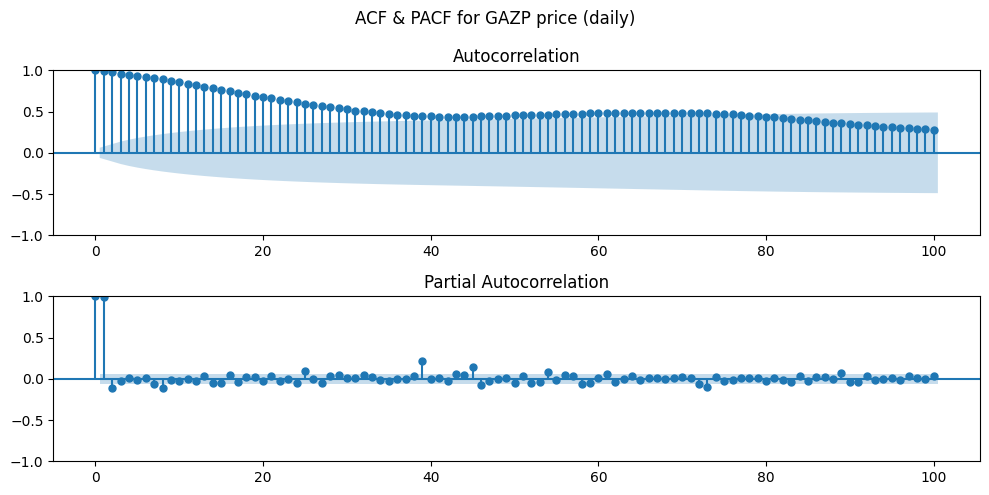

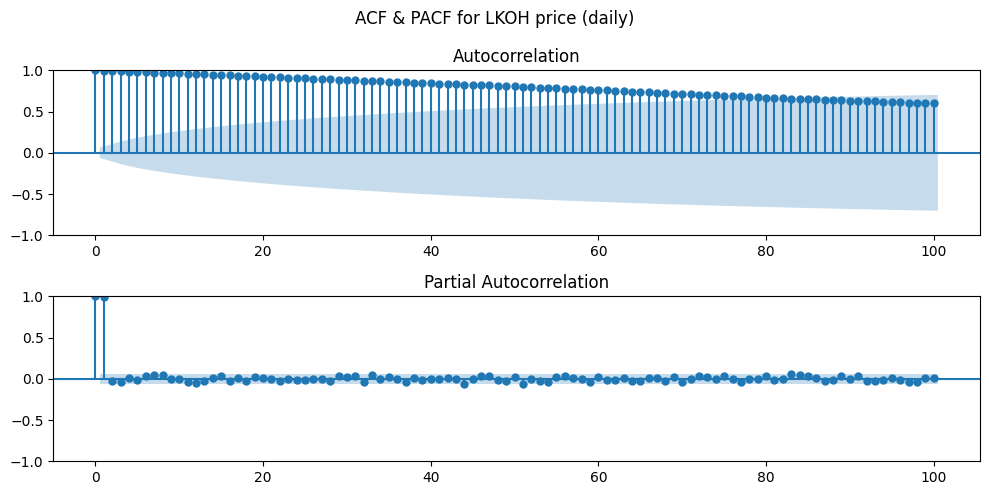

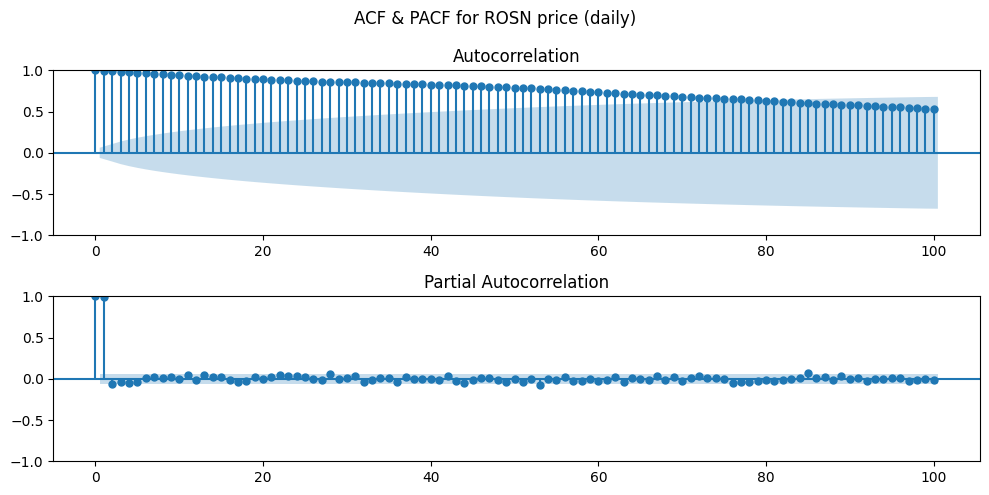

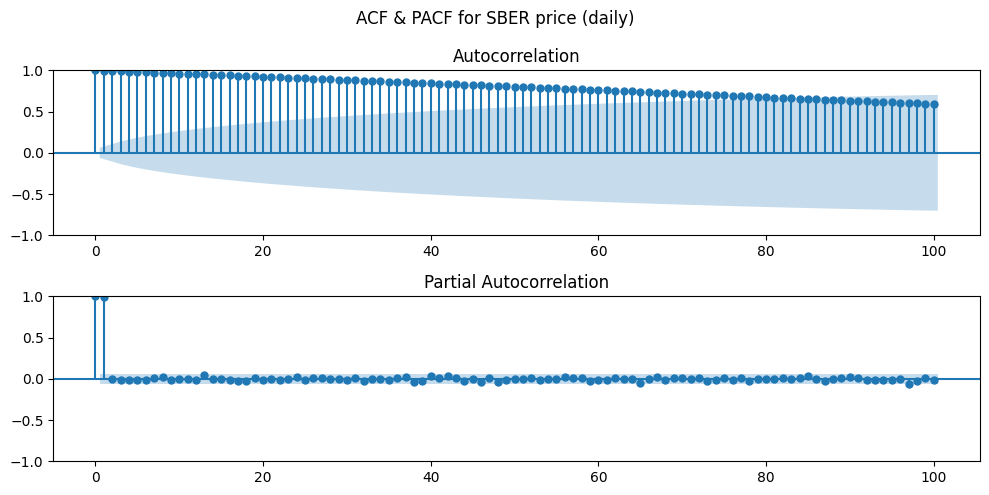

In [19]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


for ticker, df in stocks_data_daily.items():
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    fig.suptitle(f'ACF & PACF for {ticker} price (daily)')
    plot_acf(df['close'], lags=100, ax=ax[0])
    plot_pacf(df['close'], lags=100, ax=ax[1])
    plt.tight_layout()
    plt.show()

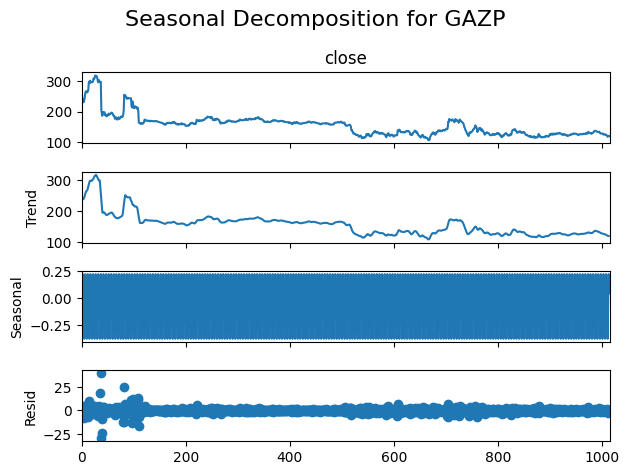

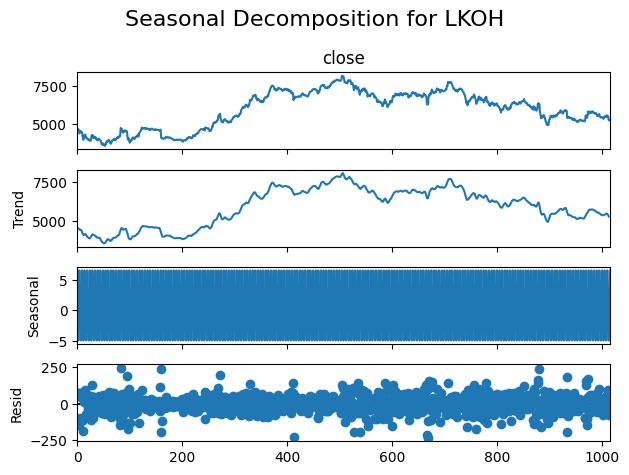

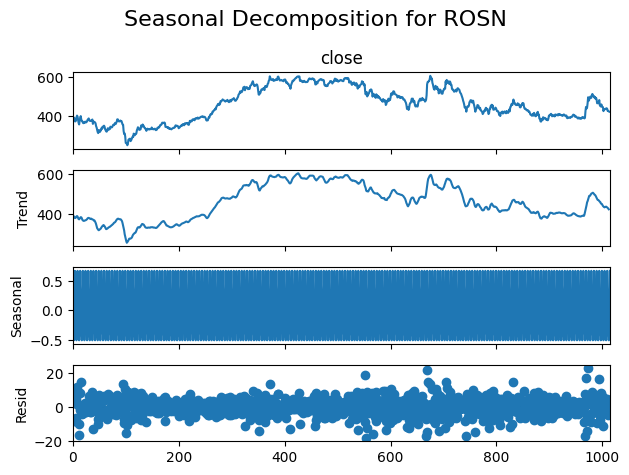

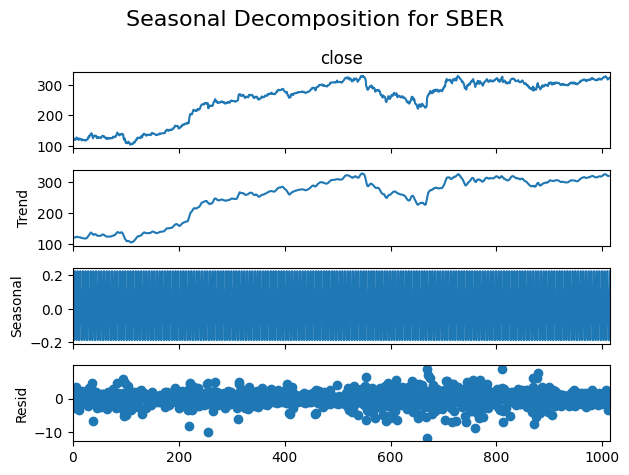

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

for ticker, df in stocks_data_daily.items():
    res = seasonal_decompose(df['close'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [21]:
stocks_data_1w_daily_df = pd.concat(stocks_data_daily.values(), keys=stocks_data_daily.keys()).reset_index(level=0).rename(columns={'level_0': 'company'})

In [22]:
fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=df['close'],
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily)",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)
fig.show()

In [23]:
# Log scale

fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=np.log(df['close']),
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily, Log Scale)",
    xaxis_title="Date",
    yaxis_title="Log(Price)",
    template="plotly_white"
)
fig.show()

Итоги исследования цены акций:
- Сезонность присутствует, но почти незаметная
- График ACF медленно падает. Есть тренд.
- На графике PACF все значения, кроме 1, находятся около "синей зоны".

Получается, что есть зависимость между многими предыдущими значениями, но прямых зависимостей нет.

Модели сложно будет адекватно предсказать такое. Попробуем взять что-нибудь другое в качестве target.

### 1.4. Анализ доходности

Попробуем взять не цену акций, а доходность акции, если купим сегодня, а продадим через неделю.

Возьмем log доходность:
$$
r_{t} = \log(P_{t}) - \log(P_{t-1})
$$

In [24]:
# Посчитаем log доходность для всех акций

stocks_returns_daily = {}

for ticker, df in stocks_data_daily.items():
    df = df.copy()
    df['target_log_return_5d'] = forward_log_return(df['close'], periods=5)
    df['target_log_return_1d'] = forward_log_return(df['close'], periods=1)
    stocks_returns_daily[ticker] = df.dropna().reset_index(drop=True)

display(stocks_returns_daily['GAZP'].tail(10))
stocks_returns_daily['GAZP'].shape

,begin,open,close,high,low,value,volume,end,ticker,target_log_return_5d,target_log_return_1d
1000,2026-04-15,128.63,128.48,129.11,128.40,3.478530e+08,2699910.0,2026-04-15 18:59:59,GAZP,-0.029462,-0.005385
1001,2026-04-16,127.86,127.79,128.02,127.74,1.818921e+08,1422740.0,2026-04-16 18:59:59,GAZP,-0.020636,-0.024878
1002,2026-04-17,124.45,124.65,124.68,124.17,5.835839e+08,4690070.0,2026-04-17 18:59:59,GAZP,-0.010646,0.009581
1003,2026-04-20,125.55,125.85,126.17,125.11,6.591773e+08,5237250.0,2026-04-20 18:59:59,GAZP,-0.020795,-0.001590
1004,2026-04-21,125.91,125.65,126.05,125.64,2.980669e+08,2368820.0,2026-04-21 18:59:59,GAZP,-0.041021,-0.007189
1005,2026-04-22,125.15,124.75,125.36,124.75,1.305176e+08,1042550.0,2026-04-22 18:59:59,GAZP,-0.057918,0.003441
1006,2026-04-23,125.44,125.18,125.55,125.18,1.123568e+08,896070.0,2026-04-23 18:59:59,GAZP,-0.039930,-0.014889
1007,2026-04-24,123.83,123.33,123.85,123.33,2.515863e+08,2035110.0,2026-04-24 18:59:59,GAZP,-0.021638,-0.000568
1008,2026-04-27,123.46,123.26,123.61,123.23,1.618844e+08,1312140.0,2026-04-27 18:59:07,GAZP,-0.034332,-0.021817
1009,2026-04-28,120.76,120.60,120.88,119.83,7.637191e+08,6350710.0,2026-04-28 18:59:59,GAZP,-0.004571,-0.024085


(1010, 11)

In [25]:
# График log доходности, рядом с графиком цены

from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=stocks_returns_daily['GAZP'].index, y=stocks_returns_daily['GAZP']['close'], name="price"),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=stocks_returns_daily['GAZP'].index, y=stocks_returns_daily['GAZP']['target_log_return_5d'], name="log return 5 days"),
    secondary_y=True,
)

fig.add_trace(
    go.Scatter(x=stocks_returns_daily['GAZP'].index, y=stocks_returns_daily['GAZP']['target_log_return_1d'], name="log return 1 day"),
    secondary_y=True,
)


# Add figure title
fig.update_layout(
    title_text="GAZP: Price and Log Return After 1 Week"
)

fig.update_xaxes(title_text="Date")

fig.update_yaxes(title_text="price", secondary_y=False)
fig.update_yaxes(title_text="log return", secondary_y=True)

fig.show()

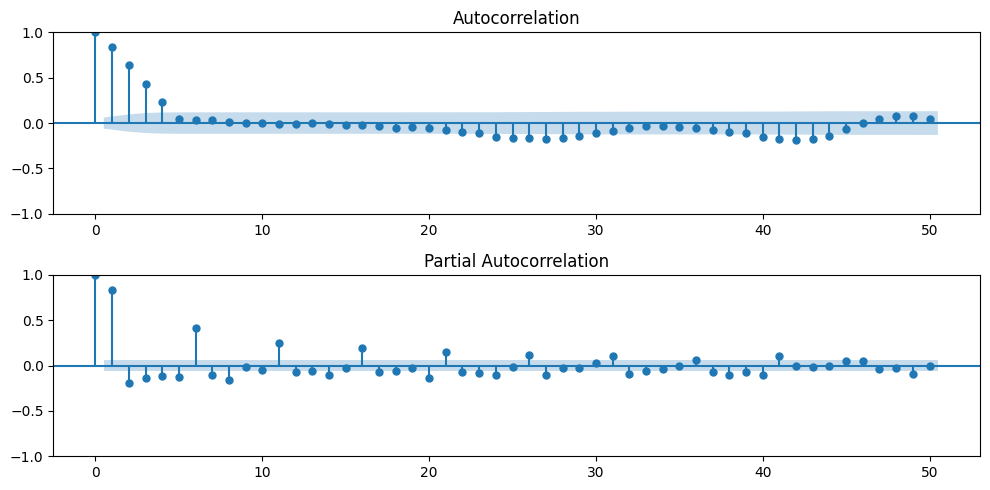

In [26]:
# Проанализируем

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_daily['GAZP']['target_log_return_5d'], lags=50, ax=ax[0]);
plot_pacf(stocks_returns_daily['GAZP']['target_log_return_5d'], lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

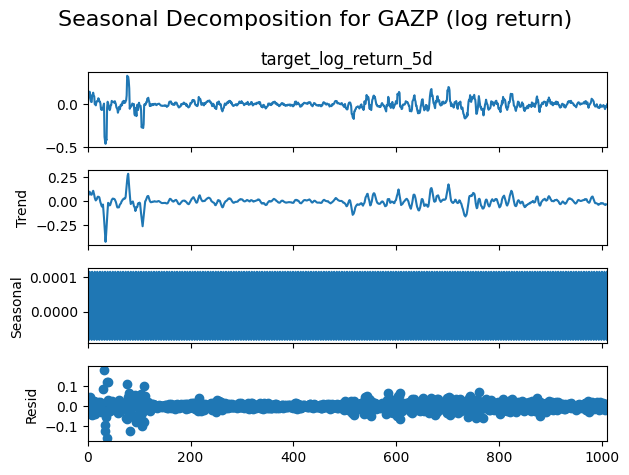

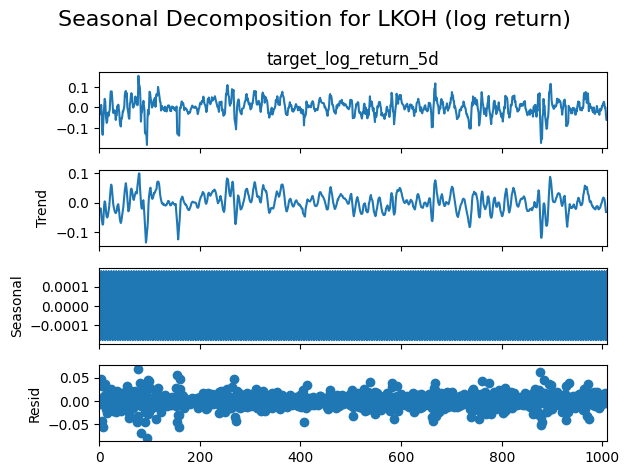

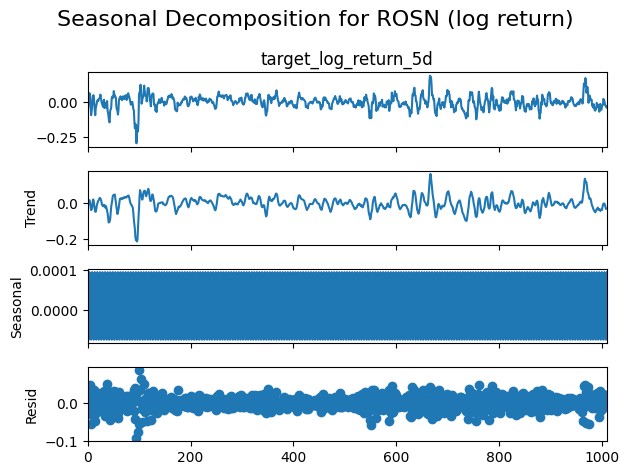

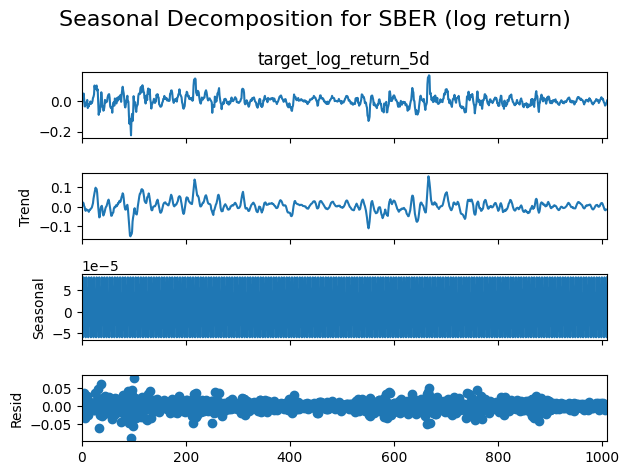

In [27]:
for ticker, df in stocks_returns_daily.items():
    res = seasonal_decompose(df['target_log_return_5d'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker} (log return)", fontsize=16)
    plt.tight_layout()
    plt.show()

Здесь мы уже видим кое что интересное.

ACF быстро затухает, за 6 дней.

А на PACF наблюдаем всплески, которые происходят примерно каждые 7 дней.

Стоит попробовать модель `AR(2)`.

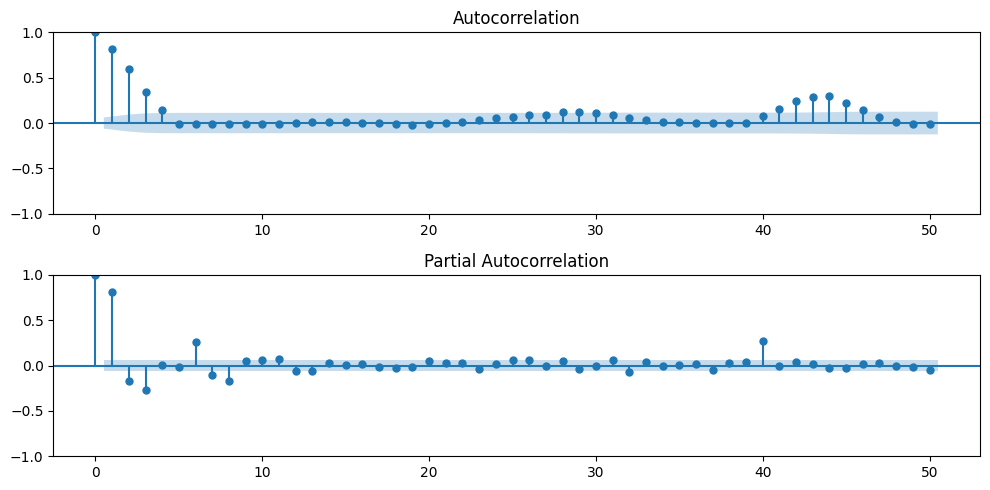

In [28]:
# Попробуем квадраты

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_daily['GAZP']['target_log_return_5d'] ** 2, lags=50, ax=ax[0]);
plot_pacf(stocks_returns_daily['GAZP']['target_log_return_5d'] ** 2, lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

## 2. SARIMA

Пробуем SARIMA модель.

Будем предсказывать Log-доходность за 1 день: предсказываем за 5 дней, суммируем и находим реальную цену.

$$
\begin{align}
&r_{t} = \log(P_{t}) - \log(P_{t-1}) \\
&S_{t,t+5} = \sum_{i=1}^5 r_i \\
&P_{t+5} = P_{t} \cdot e^{S_{t,t+5}}
\end{align}
$$


### 2.1. Baseline модель

В качестве baseilne возьмем log-доходность = 0, т.е. цена сегодня = цена через неделю

In [29]:
from typing import Protocol


# Интерфейс модели
class ForecastModel(Protocol):
    def train(self, train_df: pd.DataFrame) -> "ForecastModel":
        ...

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        ...

In [30]:
from sklearn.model_selection import TimeSeriesSplit

HORIZON = 5

# Делим выборку на train/test
# Таргет - стоимость через 5 дней, поэтому делаем gap=5
# Для теста используем 20 следующих после gap дней
tscv_5d = TimeSeriesSplit(test_size=20, n_splits=20, gap=5)
tscv_1d = TimeSeriesSplit(test_size=20, n_splits=20, gap=1)

In [31]:
# Тикер -> модель -> метрики
results = {
    'GAZP': {},
    'LKOH': {},
    'ROSN': {},
    'SBER': {},
}

In [32]:
def aggregate_predictions(y_true_oof, y_pred_oof, fold_metrics):
    oof_mse = mean_squared_error(y_true_oof, y_pred_oof)
    oof_rmse = np.sqrt(oof_mse)
    oof_r2 = r2_score(y_true_oof, y_pred_oof)

    return {
        "oof_mse": float(oof_mse),
        "oof_rmse": float(oof_rmse),
        "oof_r2": float(oof_r2),

        "fold_mse_mean": float(np.mean([m["mse"] for m in fold_metrics])),
        "fold_mse_median": float(np.median([m["mse"] for m in fold_metrics])),
        "fold_mse_std": float(np.std([m["mse"] for m in fold_metrics])),

        "fold_rmse_mean": float(np.mean([m["rmse"] for m in fold_metrics])),
        "fold_rmse_median": float(np.median([m["rmse"] for m in fold_metrics])),
        "fold_rmse_std": float(np.std([m["rmse"] for m in fold_metrics])),

        "fold_r2_mean": float(np.mean([m["r2"] for m in fold_metrics])),
        "fold_r2_median": float(np.median([m["r2"] for m in fold_metrics])),
        "fold_r2_std": float(np.std([m["r2"] for m in fold_metrics])),
    }

In [33]:
def build_prediction_frame(
    test_df: pd.DataFrame,
    pred_log_return: pd.Series | np.ndarray,
    *,
    target_col: str = "target_log_return_5d",
    price_col: str = "close",
    date_col: str = "begin",
) -> pd.DataFrame:
    pred_log_return = pd.Series(pred_log_return, index=test_df.index, name="pred_log_return")

    out = test_df[[date_col, price_col, target_col]].copy()
    out["pred_log_return"] = pred_log_return

    out["actual_future_price"] = inverse_log_return(
        out[target_col],
        out[price_col],
    )

    out["pred_future_price"] = inverse_log_return(
        out["pred_log_return"],
        out[price_col],
    )

    return out

In [34]:
from dataclasses import dataclass
from typing import Any


@dataclass
class FoldResult:
    fold_number: int
    train_start: Any
    train_end: Any
    test_start: Any
    test_end: Any
    predictions: pd.DataFrame


def evaluate_one_fold(
    model: ForecastModel,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    *,
    fold_number: int,
    target_col: str = "target_log_return_5d",
    price_col: str = "close",
    date_col: str = "begin",
) -> FoldResult:
    model.train(train_df)
    pred_log_return = model.predict(test_df)

    pred_df = build_prediction_frame(
        test_df=test_df,
        pred_log_return=pred_log_return,
        target_col=target_col,
        price_col=price_col,
        date_col=date_col,
    )

    return FoldResult(
        fold_number=fold_number,
        train_start=train_df[date_col].iloc[0],
        train_end=train_df[date_col].iloc[-1],
        test_start=test_df[date_col].iloc[0],
        test_end=test_df[date_col].iloc[-1],
        predictions=pred_df,
    )

def calculate_metrics_for_all_folds(
    folds: list[FoldResult],
    target_log_return_col: str = "target_log_return_5d",
    pred_log_return_col: str = "pred_log_return",
    actual_future_price_col: str = "actual_future_price",
    pred_future_price_col: str = "pred_future_price",
    ) -> dict[str, Any]:
    all_predictions = pd.concat(
        [fold.predictions.assign(fold_number=fold.fold_number) for fold in folds],
        ignore_index=True,
    )

    y_true_return = all_predictions[target_log_return_col].to_numpy(dtype=float)
    y_pred_return = all_predictions[pred_log_return_col].to_numpy(dtype=float)

    y_true_price = all_predictions[actual_future_price_col].to_numpy(dtype=float)
    y_pred_price = all_predictions[pred_future_price_col].to_numpy(dtype=float)

    finite = (
        np.isfinite(y_true_return)
        & np.isfinite(y_pred_return)
        & np.isfinite(y_true_price)
        & np.isfinite(y_pred_price)
    )
    if not np.any(finite):
        raise ValueError("No finite rows left for metrics (all NaN/inf).")
    y_true_return = y_true_return[finite]
    y_pred_return = y_pred_return[finite]
    y_true_price = y_true_price[finite]
    y_pred_price = y_pred_price[finite]

    return_mae = mean_absolute_error(y_true_return, y_pred_return)
    price_mae = mean_absolute_error(y_true_price, y_pred_price)

    return_mse = mean_squared_error(y_true_return, y_pred_return)
    price_mse = mean_squared_error(y_true_price, y_pred_price)

    # r2_score may be undefined if target is constant
    return_r2 = np.nan if np.allclose(y_true_return, y_true_return[0]) else r2_score(y_true_return, y_pred_return)
    price_r2 = np.nan if np.allclose(y_true_price, y_true_price[0]) else r2_score(y_true_price, y_pred_price)

    return {
        "n_folds": len(folds),
        "n_oof_predictions": int(len(y_true_return)),

        "return_mae": float(return_mae),
        "return_rmse": float(np.sqrt(return_mse)),
        "return_r2": float(return_r2) if not np.isnan(return_r2) else np.nan,

        "price_mae": float(price_mae),
        "price_rmse": float(np.sqrt(price_mse)),
        "price_r2": float(price_r2) if not np.isnan(price_r2) else np.nan,
    }

In [35]:
from typing import Callable


def run_cv_backtest(
    model_factory: Callable[[], ForecastModel],
    df: pd.DataFrame,
    splitter,
    *,
    target_col: str = "target_log_return_5d",
    price_col: str = "close",
    date_col: str = "begin",
    verbose: bool = True,
) -> dict[str, Any]:
    fold_results: list[FoldResult] = []

    for fold_number, (train_index, test_index) in tqdm(enumerate(splitter.split(df), start=1), position=2, leave=False, desc='Folds'):
        train_df = df.iloc[train_index].copy()
        test_df = df.iloc[test_index].copy()

        model = model_factory()

        fold_result = evaluate_one_fold(
            model=model,
            train_df=train_df,
            test_df=test_df,
            fold_number=fold_number,
            target_col=target_col,
            price_col=price_col,
            date_col=date_col,
        )
        fold_results.append(fold_result)

        if verbose:
            print(f"Fold {fold_number}:")
            print(f"  Train: {fold_result.train_start} - {fold_result.train_end} ({len(train_df)} rows)")
            print(f"  Test : {fold_result.test_start} - {fold_result.test_end} ({len(test_df)} rows)")
            print()

    all_predictions = pd.concat([fr.predictions.assign(fold=fr.fold_number) for fr in fold_results], axis=0)

    return {
        "fold_results": fold_results,
        "predictions": all_predictions,
    }

In [36]:
class ZeroReturnBaseline():
    def __init__(self, target_col: str = "target_log_return_5d"):
        self.target_col = target_col

    def train(self, train_df: pd.DataFrame):
        return self

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        return pd.Series(
            data=np.zeros(len(test_df), dtype=float),
            index=test_df.index,
            name="pred_log_return",
        )

In [37]:
def run_and_calculate_metrics(df_by_ticker, model_factory, verbose=False):
    out = {}
    for ticker, df in tqdm(df_by_ticker.items(), position=0, desc='Tickers'):
        print(f"{ticker}: {df['begin'].min()} - {df['begin'].max()} ({len(df)} rows)")

        cv_result = run_cv_backtest(
            model_factory=model_factory,
            df=df,
            splitter=tscv_5d,
            target_col="target_log_return_5d",
            price_col="close",
            date_col="begin",
            verbose=verbose,
        )

        out[ticker] = calculate_metrics_for_all_folds(cv_result["fold_results"])
    return out

In [38]:
for ticker, metrics in run_and_calculate_metrics(
    stocks_returns_daily,
    lambda: ZeroReturnBaseline(target_col="target_log_return_5d"),
).items():
    results[ticker]["baseline"] = metrics

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

GAZP: 2022-05-04 00:00:00 - 2026-04-28 00:00:00 (1010 rows)


Folds: 0it [00:00, ?it/s]

LKOH: 2022-05-04 00:00:00 - 2026-04-28 00:00:00 (1010 rows)


Folds: 0it [00:00, ?it/s]

ROSN: 2022-05-04 00:00:00 - 2026-04-28 00:00:00 (1010 rows)


Folds: 0it [00:00, ?it/s]

SBER: 2022-05-04 00:00:00 - 2026-04-28 00:00:00 (1010 rows)


Folds: 0it [00:00, ?it/s]

### 2.2. Обучение SARIMA и сравнение с baseilne

In [39]:
# Теперь SARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX


class SarimaxDirectModel:
    def __init__(
        self,
        exog_cols: list[str] = None,
        target_col: str = "target_log_return_5d",
        order=(1, 0, 0),
        seasonal_order=(0, 0, 0, 0),
        method='lbfgs',
    ):
        self.exog_cols = exog_cols or []
        self.target_col = target_col
        self.order = order
        self.seasonal_order = seasonal_order
        self.method = method
        self.fitted = None

    def train(self, train_df: pd.DataFrame):
        y_train = train_df[self.target_col]
        X_train = train_df[self.exog_cols] if self.exog_cols else None

        model = SARIMAX(
            endog=y_train,
            exog=X_train,
            order=self.order,
            seasonal_order=self.seasonal_order,
            trend="c",
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        self.fitted = model.fit(disp=False, method=self.method)
        return self

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        if self.fitted is None:
            raise RuntimeError("Call train before predict")

        X_test = test_df[self.exog_cols] if self.exog_cols else None
        fc = (
            self.fitted.get_forecast(steps=len(test_df), exog=X_test)
            if X_test is not None
            else self.fitted.get_forecast(steps=len(test_df))
        )
        pred = fc.predicted_mean

        return pd.Series(pred, index=test_df.index, name="pred_log_return")

    def feature_importance(self) -> pd.Series:
        if self.fitted is None:
            raise RuntimeError("Call train() before feature_importance().")

        if not self.exog_cols:
            return pd.Series(dtype=float)  # no exog => no "feature" importances

        params = self.fitted.params
        # params is a pandas Series; exog params are usually named like 'x1', or the column names
        # If statsmodels preserved column names, you'll see them directly.
        out = params.reindex(self.exog_cols).dropna()
        return out.abs().sort_values(ascending=False)

In [40]:
for order in [(1, 0, 0), (2, 0, 0), (1, 0, 1)]:
    key = f"SARIMA({', '.join(map(str, order))})"
    for ticker, metrics in run_and_calculate_metrics(
        stocks_returns_daily,
        lambda o=order: SarimaxDirectModel(
            target_col="target_log_return_5d",
            order=o,
        ),
    ).items():
        results[ticker][key] = metrics

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

GAZP: 2022-05-04 00:00:00 - 2026-04-28 00:00:00 (1010 rows)


Folds: 0it [00:00, ?it/s]

/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



LKOH: 2022-05-04 00:00:00 - 2026-04-28 00:00:00 (1010 rows)


...

/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Folds: 0it [00:00, ?it/s]

SBER: 2022-05-04 00:00:00 - 2026-04-28 00:00:00 (1010 rows)


Folds: 0it [00:00, ?it/s]

/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [41]:
def results_as_table(results):
    rows = []
    for ticker, models in results.items():
        for model_name, metrics in models.items():
            row = {
                'Ticker': ticker,
                'Model': model_name,
                'Folds': metrics['n_folds'],
                'Predictions': metrics['n_oof_predictions'],
                'Return MAE': metrics['return_mae'],
                'Return RMSE': metrics['return_rmse'],
                'Return R2': metrics['return_r2'],
                'Price MAE': metrics['price_mae'],
                'Price RMSE': metrics['price_rmse'],
                'Price R2': metrics['price_r2'],
            }
            rows.append(row)
    return pd.DataFrame(rows).sort_values(['Ticker', 'Price R2'], ascending=(True, False))

In [42]:
results_as_table(results)

,Ticker,Model,Folds,Predictions,Return MAE,Return RMSE,Return R2,Price MAE,Price RMSE,Price R2
0,GAZP,baseline,20,400,0.038999,0.053576,-0.000925,5.178375,7.289460,0.705486
2,GAZP,"SARIMA(2, 0, 0)",20,300,0.039494,0.054318,-0.026498,5.280014,7.536751,0.677027
3,GAZP,"SARIMA(1, 0, 1)",20,300,0.039661,0.054551,-0.035338,5.306223,7.572442,0.673961
1,GAZP,"SARIMA(1, 0, 0)",20,300,0.039871,0.054966,-0.051142,5.341559,7.638227,0.668271
4,LKOH,baseline,20,400,0.027857,0.038132,-0.007364,172.793750,234.351276,0.885549
6,LKOH,"SARIMA(2, 0, 0)",20,300,0.028553,0.039091,-0.038613,178.636989,242.522306,0.872691
7,LKOH,"SARIMA(1, 0, 1)",20,300,0.028683,0.039264,-0.047834,179.559398,243.843862,0.871299
5,LKOH,"SARIMA(1, 0, 0)",20,300,0.029037,0.039667,-0.069449,181.947874,246.810318,0.868149
10,ROSN,"SARIMA(2, 0, 0)",20,300,0.033312,0.044190,-0.038590,15.444581,20.805337,0.837091
11,ROSN,"SARIMA(1, 0, 1)",20,300,0.033512,0.044482,-0.052381,15.540753,20.966224,0.834561


Модель SARIMA справилась примерно на уровне наивного бэйзлайна


### 2.3. Дополнительные признаки

Попробуем добавить признаки к SARIMA модели. Сначала спарсим и обработаем их.

Используем эти признаки:
- `GLDRUB_TOM` - спотовая стоимость золота
- `USDRUBF`, `EURRUBF`, `CNYRUBF` - стоимость вечных фьючерсов на USD, EUR, CNY. Для SARIMAX возьмем только `USDRUBF`.
- `IMOEX` - индекс Мосбиржи
- Стоимость фьючерсов на нефть Brent

In [43]:
# Спарсим золото

gold_data = await moex_client.get_data(
    tickers=['GLDRUB_TOM'],
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
gold_df = gold_data['GLDRUB_TOM'].copy()
gold_df.tail(10)

,open,close,high,low,value,volume,begin,end,ticker
11420,11015.3,11015.3,11015.3,11015.3,13416635.4,1218,2026-05-05 09:00:00,2026-05-05 09:59:59,GLDRUB_TOM
11421,11025.0,10966.7,11036.9,10960.2,443097610.7,40332,2026-05-05 10:00:00,2026-05-05 10:59:59,GLDRUB_TOM
11422,10969.4,11034.9,11041.1,10967.0,575294924.4,52275,2026-05-05 11:00:00,2026-05-05 11:59:59,GLDRUB_TOM
11423,11031.5,11043.4,11050.0,11020.5,175024026.3,15866,2026-05-05 12:00:00,2026-05-05 12:59:59,GLDRUB_TOM
11424,11033.3,10993.8,11042.8,10993.8,248656982.0,22585,2026-05-05 13:00:00,2026-05-05 13:59:59,GLDRUB_TOM
11425,10994.9,11085.0,11095.7,10990.0,269360118.0,24382,2026-05-05 14:00:00,2026-05-05 14:59:59,GLDRUB_TOM
11426,11096.1,11093.4,11100.0,11064.1,312625918.0,28196,2026-05-05 15:00:00,2026-05-05 15:59:59,GLDRUB_TOM
11427,11096.8,11097.9,11125.0,11092.5,300902853.8,27085,2026-05-05 16:00:00,2026-05-05 16:59:59,GLDRUB_TOM
11428,11098.0,11107.9,11116.5,11075.0,307182665.0,27655,2026-05-05 17:00:00,2026-05-05 17:59:59,GLDRUB_TOM
11429,11109.8,11097.3,11120.0,11083.3,107675530.0,9688,2026-05-05 18:00:00,2026-05-05 18:59:59,GLDRUB_TOM


In [44]:
# Валюты

currencies_prices = await moex_client.get_data(
    tickers=['USDRUBF', 'EURRUBF', 'CNYRUBF'],
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
currencies_prices

{'USDRUBF':         open  close   high    low  value  volume               begin  \
 0      71.87  72.00  72.88  70.27      0    1735 2022-05-04 10:00:00   
 1      71.91  70.62  71.94  70.43      0    1280 2022-05-04 11:00:00   
 2      70.59  70.27  70.70  70.10      0    1167 2022-05-04 12:00:00   
 3      70.29  70.27  70.57  70.12      0     453 2022-05-04 13:00:00   
 4      70.27  70.55  70.71  70.27      0     426 2022-05-04 14:00:00   
 ...      ...    ...    ...    ...    ...     ...                 ...   
 15370  75.83  75.79  75.92  75.75      0   13591 2026-05-05 15:00:00   
 15371  75.79  75.68  75.82  75.66      0    5783 2026-05-05 16:00:00   
 15372  75.68  75.66  75.74  75.61      0    7332 2026-05-05 17:00:00   
 15373  75.67  75.70  75.74  75.65      0    7753 2026-05-05 18:00:00   
 15374  75.70  75.70  75.75  75.68      0    3131 2026-05-05 19:00:00   
 
                       end   ticker  
 0     2022-05-04 10:59:59  USDRUBF  
 1     2022-05-04 11:59:59  USDRUBF

In [45]:
imoex_data = await moex_client.get_data(
    tickers=['IMOEX'],
    engine=Engines.STOCK,
    market=Markets.INDEX,
    board=Boards.RFUD,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
imoex_df = imoex_data['IMOEX'].copy()
imoex_df.tail(10)

,open,close,high,low,value,volume,begin,end,ticker
9470,2619.54,2609.91,2627.41,2609.68,3.374773e+09,0,2026-05-05 10:00:00,2026-05-05 10:59:59,IMOEX
9471,2609.83,2601.47,2611.41,2590.66,8.948478e+09,0,2026-05-05 11:00:00,2026-05-05 11:59:59,IMOEX
9472,2601.29,2623.32,2627.05,2597.24,6.756917e+09,0,2026-05-05 12:00:00,2026-05-05 12:59:59,IMOEX
9473,2623.32,2621.42,2630.67,2614.77,4.345590e+09,0,2026-05-05 13:00:00,2026-05-05 13:59:59,IMOEX
9474,2621.39,2622.40,2624.93,2617.73,2.790899e+09,0,2026-05-05 14:00:00,2026-05-05 14:59:59,IMOEX
9475,2622.38,2637.49,2639.39,2622.38,6.080730e+09,0,2026-05-05 15:00:00,2026-05-05 15:59:59,IMOEX
9476,2637.47,2647.10,2648.57,2635.22,5.483730e+09,0,2026-05-05 16:00:00,2026-05-05 16:59:59,IMOEX
9477,2647.05,2650.94,2651.78,2644.23,4.891205e+09,0,2026-05-05 17:00:00,2026-05-05 17:59:59,IMOEX
9478,2651.02,2644.43,2652.25,2643.51,3.070095e+09,0,2026-05-05 18:00:00,2026-05-05 18:59:01,IMOEX
9479,2644.37,2644.37,2644.37,2644.37,0.000000e+00,0,2026-05-05 19:00:00,2026-05-05 19:04:02,IMOEX


In [46]:
# Нефть
# С ней немного поколдуем. Вечного фьючерса нет, поэтому придётся склеить несколько фьючерсов вместе.
# Код взял из parsing_currencies_n_metals.ipynb

import aiohttp


def generate_all_brent_tickers(start_year=2022, end_year=2026):
    month_codes = {
        1: 'F', 2: 'G', 3: 'H', 4: 'J', 5: 'K', 6: 'M',
        7: 'N', 8: 'Q', 9: 'U', 10: 'V', 11: 'X', 12: 'Z'
    }
    year_codes = {2022: '2', 2023: '3', 2024: '4', 2025: '5', 2026: '6', 2027: '7'}
    
    tickers = []
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            ticker = f"BR{month_codes[month]}{year_codes[year]}"
            expiry_date = pd.Timestamp(year=year, month=month, day=1)
            tickers.append({'ticker': ticker, 'expiry': expiry_date})
    
    return pd.DataFrame(tickers)


async def get_brent_futures_metadata():
    url = "https://iss.moex.com/iss/engines/futures/markets/forts/boards/RFUD/securities.json"
    async with aiohttp.ClientSession() as session:
        async with session.get(url) as response:
            data = await response.json()
    
    securities = data['securities']
    df_active = pd.DataFrame(securities['data'], columns=securities['columns'])
    df_active = df_active[df_active['SECID'].str.startswith('BR') & ~df_active['SECID'].str.startswith('BRM')]
    df_active['LASTTRADEDATE'] = pd.to_datetime(df_active['LASTTRADEDATE'])
    df_active = df_active[['SECID', 'LASTTRADEDATE']].rename(columns={'SECID': 'ticker', 'LASTTRADEDATE': 'expiry'})
    df_active = df_active.dropna()
    
    df_all = generate_all_brent_tickers(2022, 2027)
    
    for idx, row in df_active.iterrows():
        mask = df_all['ticker'] == row['ticker']
        if mask.any():
            df_all.loc[mask, 'expiry'] = row['expiry']
    
    return df_all.sort_values('expiry').reset_index(drop=True)

In [47]:
futures_meta = await get_brent_futures_metadata()

tickers = futures_meta['ticker'].tolist()

brent_data = await moex_client.get_data(
    tickers=tickers,
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
brent_data.keys()

dict_keys(['BRF2', 'BRG2', 'BRH2', 'BRJ2', 'BRK2', 'BRM2', 'BRN2', 'BRQ2', 'BRU2', 'BRV2', 'BRX2', 'BRZ2', 'BRF3', 'BRG3', 'BRH3', 'BRJ3', 'BRK3', 'BRM3', 'BRN3', 'BRQ3', 'BRU3', 'BRV3', 'BRX3', 'BRZ3', 'BRF4', 'BRG4', 'BRH4', 'BRJ4', 'BRK4', 'BRM4', 'BRN4', 'BRQ4', 'BRU4', 'BRV4', 'BRX4', 'BRZ4', 'BRF5', 'BRG5', 'BRH5', 'BRJ5', 'BRK5', 'BRM5', 'BRN5', 'BRQ5', 'BRU5', 'BRV5', 'BRX5', 'BRZ5', 'BRF6', 'BRG6', 'BRH6', 'BRJ6', 'BRK6', 'BRM6', 'BRN6', 'BRQ6', 'BRU6', 'BRV6', 'BRX6', 'BRZ6', 'BRF7', 'BRG7', 'BRH7', 'BRJ7', 'BRK7', 'BRM7', 'BRN7', 'BRQ7', 'BRU7', 'BRV7', 'BRX7', 'BRZ7'])

In [48]:
from datetime import timedelta


def count_trading_days(start_date, end_date):
    if pd.isna(start_date) or pd.isna(end_date):
        return 0
    if isinstance(start_date, pd.Timestamp):
        start_date = start_date.date()
    if isinstance(end_date, pd.Timestamp):
        end_date = end_date.date()
    
    trading_days = 0
    current = start_date
    while current < end_date:
        if current.weekday() < 5:
            trading_days += 1
        current += timedelta(days=1)
    return trading_days


def select_contract(timestamp_t, futures_meta, all_data, roll_window=5):
    """
    Select the nearest-expiring futures contract for a given timestamp,
    subject to a minimum roll window in trading days.

    Parameters
    ----------
    timestamp_t : datetime-like
        The timestamp at which we want a contract (e.g. bar time).
    futures_meta : pd.DataFrame
        Must contain columns:
            - 'ticker' : str
            - 'expiry' : datetime64[ns] or convertible to datetime
        One row per contract.
    all_data : dict[str, pd.DataFrame]
        Mapping from ticker -> DataFrame with at least:
            - 'begin' : datetime64[ns] (bar start time)
    roll_window : int
        Minimum number of trading days to expiry to allow using this contract.

    Returns
    -------
    str | None
        Selected contract ticker, or None if no suitable contract has data
        at the given timestamp.
    """

    # Normalize timestamp
    timestamp_t = pd.Timestamp(timestamp_t)

    # Work in date space for roll logic
    date_t = timestamp_t.date()
    # Don't include contracts that expire more than 3 months from now
    date_t_max = date_t + timedelta(days=90)

    # Ensure expiry is proper datetime64[ns]
    futures_meta = futures_meta.copy()
    futures_meta['expiry'] = pd.to_datetime(futures_meta['expiry'])

    # Convert date_t and date_t_max to Timestamp so types match expiry (datetime64[ns])
    start_ts = pd.to_datetime(date_t)       # midnight of current date
    end_ts = pd.to_datetime(date_t_max)     # midnight of max date

    # Contracts whose expiry is strictly after current date and before date_t_max
    available = futures_meta.loc[
        (futures_meta['expiry'] > start_ts) &
        (futures_meta['expiry'] < end_ts)
    ].copy()

    if available.empty:
        return None

    # Compute days to expiry for each contract using trading days
    # Here we go back to pure `date` for count_trading_days
    available['days_to_expiry'] = available['expiry'].dt.date.apply(
        lambda d: count_trading_days(date_t, d)
    )

    # Keep only contracts that satisfy the roll_window constraint
    candidates = available.loc[available['days_to_expiry'] >= roll_window]
    if candidates.empty:
        return None

    # Sort so the nearest expiry (smallest days_to_expiry) is considered first
    candidates = candidates.sort_values(['days_to_expiry', 'expiry'])

    def has_bar_at_timestamp(ticker: str) -> bool:
        """Check that the given contract has data at timestamp_t."""
        df = all_data.get(ticker)
        if df is None or df.empty:
            return False
        return not df.loc[df['begin'] == timestamp_t].empty

    # Choose the nearest-expiring candidate that actually has a bar at this time
    for ticker in candidates['ticker']:
        if has_bar_at_timestamp(ticker):
            return ticker

    # No candidate contract had data at this timestamp
    return None



async def build_brent_continuous(start_date, end_date, all_data, futures_meta, roll_window=5):
    print(f"\nBuilding continuous series (roll_window={roll_window})...")
    all_timestamps = pd.date_range(start=start_date, end=end_date, freq='H')
    trading_timestamps = [ts for ts in all_timestamps if ts.weekday() < 5]
    
    rows = []
    missing_data_count = 0
    
    for timestamp_t in trading_timestamps:
        ticker = select_contract(timestamp_t, futures_meta, all_data, roll_window)
        
        if ticker:
            contract_data = all_data[ticker]
            ts_data = contract_data[contract_data['begin'] == timestamp_t]
            row = ts_data.iloc[0]
            expiry = futures_meta[futures_meta['ticker'] == ticker]['expiry'].iloc[0]
            rows.append({
                'begin': timestamp_t,
                'open': row['open'],
                'high': row['high'],
                'low': row['low'],
                'close': row['close'],
                'volume': row['volume'],
                'value': row['value'],
                'ticker': ticker,
                'expiry': expiry,
                'days_to_expiry': count_trading_days(timestamp_t.date(), expiry.date())
            })
        else:
            missing_data_count += 1
    
    df = pd.DataFrame(rows)
    print(f"\n✓ Generated {len(df)} data points from {df['begin'].min()} to {df['begin'].max()}")
    if missing_data_count > 0:
        print(f"⚠ Missing {missing_data_count} timestamps (no contract had data)")
    return df

In [49]:
brent_continuous = await build_brent_continuous(date_start, datetime.now(), brent_data, futures_meta, roll_window=5)
brent_continuous


Building continuous series (roll_window=5)...


/tmp/ipykernel_262179/2237734350.py:106: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.




✓ Generated 15400 data points from 2022-05-04 10:00:00 to 2026-05-05 19:00:00
⚠ Missing 9725 timestamps (no contract had data)


,begin,open,high,low,close,volume,value,ticker,expiry,days_to_expiry
0,2022-05-04 10:00:00,106.70,107.58,105.09,107.16,12835,0,BRM2,2022-06-01,20
1,2022-05-04 11:00:00,107.19,108.58,107.16,108.03,15638,0,BRM2,2022-06-01,20
2,2022-05-04 12:00:00,108.03,108.74,107.62,108.69,9380,0,BRM2,2022-06-01,20
3,2022-05-04 13:00:00,108.67,108.95,108.37,108.50,9165,0,BRM2,2022-06-01,20
4,2022-05-04 14:00:00,108.44,108.94,108.25,108.73,7403,0,BRM2,2022-06-01,20
...,...,...,...,...,...,...,...,...,...,...
15395,2026-05-05 15:00:00,112.81,113.26,111.67,112.37,133127,0,BRM6,2026-06-01,19
15396,2026-05-05 16:00:00,112.37,112.51,111.21,111.39,93039,0,BRM6,2026-06-01,19
15397,2026-05-05 17:00:00,111.38,112.29,110.41,111.25,224297,0,BRM6,2026-06-01,19
15398,2026-05-05 18:00:00,111.24,111.65,110.24,110.91,107345,0,BRM6,2026-06-01,19


In [50]:
def group_by_daily(df):
    df = df.sort_values('begin').assign(begin=lambda df: df['begin'].dt.date).groupby('begin', as_index=False).last()[['begin', 'close']]
    df['begin'] = pd.to_datetime(df['begin'])
    return df

In [51]:
group_by_daily(gold_df).head()

,begin,close
0,2022-05-04,3885.00
1,2022-05-05,4050.00
2,2022-05-06,4169.99
3,2022-05-11,4050.00
4,2022-05-12,3842.00


In [52]:
# Проверим, совпадает ли результат group_by_daily с данными с MOEX
(await moex_client.get_data(
    tickers=['GLDRUB_TOM'],
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.DAY_1,
))['GLDRUB_TOM']

,open,close,high,low,value,volume,begin,end,ticker
0,4240.00,3885.00,4249.44,3597.25,1.489730e+08,36914,2022-05-04,2022-05-04 23:59:59,GLDRUB_TOM
1,3958.86,4050.00,4200.00,3900.01,8.836315e+07,21853,2022-05-05,2022-05-05 23:59:59,GLDRUB_TOM
2,4012.54,4169.99,4198.88,3850.00,1.084164e+08,27101,2022-05-06,2022-05-06 23:59:59,GLDRUB_TOM
3,4123.16,4050.00,4198.88,4000.00,7.151772e+07,17384,2022-05-11,2022-05-11 23:59:59,GLDRUB_TOM
4,4050.00,3842.00,4073.91,3710.00,1.056021e+08,27455,2022-05-12,2022-05-12 23:59:59,GLDRUB_TOM
...,...,...,...,...,...,...,...,...,...
1012,11025.00,10985.00,11095.40,10898.10,4.791950e+09,435960,2026-04-28,2026-04-28 23:59:59,GLDRUB_TOM
1013,10985.00,10835.80,11001.50,10777.50,4.757930e+09,437206,2026-04-29,2026-04-29 23:59:59,GLDRUB_TOM
1014,10975.00,11080.00,11100.00,10961.50,4.847758e+09,439053,2026-04-30,2026-04-30 23:59:59,GLDRUB_TOM
1015,11039.60,10957.20,11120.80,10927.30,5.613747e+09,508723,2026-05-04,2026-05-04 23:59:59,GLDRUB_TOM


In [53]:
# Добавляем всё в один датафрейм

dates = stocks_returns_daily['GAZP']['begin']
stocks_df = pd.DataFrame({'begin': dates})
for ticker, df in stocks_returns_daily.items():
    stocks_df = stocks_df.merge(df[['begin', 'close', 'target_log_return_5d']], on='begin', how='left').rename(columns={'close': f'{ticker}_close', 'target_log_return_5d': f'{ticker}_target_log_return_5d'})

stocks_df = stocks_df.merge(group_by_daily(gold_df), on='begin', how='left').rename(columns={'close': 'GOLD_close'})
stocks_df = stocks_df.merge(group_by_daily(imoex_df), on='begin', how='left').rename(columns={'close': 'IMOEX_close'})
stocks_df = stocks_df.merge(group_by_daily(brent_continuous), on='begin', how='left').rename(columns={'close': 'BRENT_close'})
stocks_df = stocks_df.merge(group_by_daily(currencies_prices['USDRUBF']), on='begin', how='left').rename(columns={'close': 'USDRUBF_close'})
stocks_df = stocks_df.merge(group_by_daily(currencies_prices['EURRUBF']), on='begin', how='left').rename(columns={'close': 'EURRUBF_close'})
stocks_df = stocks_df.merge(group_by_daily(currencies_prices['CNYRUBF']), on='begin', how='left').rename(columns={'close': 'CNYRUBF_close'})
stocks_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
0,2022-05-04,234.16,0.005791,4552.0,-0.038518,396.20,-0.055126,123.20,-0.024652,3885.00,2373.16,107.35,68.89,73.00,10.50
1,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,2404.80,111.80,68.86,72.80,10.76
2,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,2393.03,112.00,70.36,74.96,10.96
3,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,2387.14,106.67,68.20,71.80,10.59
4,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,2297.89,108.18,64.10,66.81,9.98


In [54]:
stocks_df.describe()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
count,1010,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1009.000000,1009.000000,1010.000000,1009.000000,1009.000000,1009.000000
mean,2024-04-30 08:07:36.237623808,155.829624,-0.003388,5919.968317,0.000754,460.151634,0.000426,251.569426,0.004741,6935.567641,2760.935263,81.288406,82.491615,90.068632,11.565356
min,2022-05-04 00:00:00,106.600000,-0.463945,3539.500000,-0.181210,254.000000,-0.295639,103.830000,-0.224959,2974.500000,1916.970000,59.020000,54.570000,55.420000,8.350000
25%,2023-05-03 06:00:00,127.855000,-0.022377,4720.500000,-0.019897,390.212500,-0.022581,229.610000,-0.013724,5124.920000,2524.380000,72.300000,76.860000,87.150000,10.945000
50%,2024-04-29 12:00:00,158.490000,-0.002082,6208.250000,0.000000,458.050000,0.000738,273.810000,0.004093,6654.800000,2774.410000,80.300000,82.350000,93.630000,11.560000
75%,2025-04-28 18:00:00,169.280000,0.019347,6929.375000,0.022752,538.525000,0.025903,305.417500,0.021448,8571.800000,3076.260000,87.405000,91.320000,99.310000,12.645000
max,2026-04-28 00:00:00,317.690000,0.332315,8142.000000,0.152282,605.600000,0.189104,328.780000,0.173699,13345.900000,3501.890000,125.200000,108.710000,114.280000,14.750000
std,NaN,36.154590,0.060009,1210.359046,0.038940,85.620116,0.045194,67.151890,0.036765,2587.666596,372.643564,12.771940,11.770552,13.598860,1.394979


In [55]:
tickers = ['GAZP', 'LKOH', 'ROSN', 'SBER', 'GOLD', 'IMOEX', 'BRENT', 'USDRUBF', 'EURRUBF', 'CNYRUBF']

In [56]:
stocks_df = stocks_df.dropna().reset_index(drop=True)
stocks_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
0,2022-05-04,234.16,0.005791,4552.0,-0.038518,396.20,-0.055126,123.20,-0.024652,3885.00,2373.16,107.35,68.89,73.00,10.50
1,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,2404.80,111.80,68.86,72.80,10.76
2,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,2393.03,112.00,70.36,74.96,10.96
3,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,2387.14,106.67,68.20,71.80,10.59
4,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,2297.89,108.18,64.10,66.81,9.98


In [57]:
# Сгенерируем лаговые признаки
# Остальные брать не будем. Курсы валют коррелируют с USDRUBF,
# а вместо стоимости отдельных тикеров возьмем индекс MOEX по крупнейшим компаниям РФ
exog_tickers = ['GOLD', 'IMOEX', 'BRENT', 'USDRUBF']
tickers_to_predict = ['GAZP', 'LKOH', 'ROSN', 'SBER']

stocks_returns_df = stocks_df.copy()
for ticker in tickers:
    if ticker in exog_tickers:
        ticker_col = f'{ticker}_close'
        # Для внешних признаков генерируем лаговые лог-доходности: log(сегодня/вчера), log(вчера/позавчера) и т.п.
        for lag in [0, 1, 2, 5]:
            stocks_returns_df[f'{ticker}_log_return_lag{lag}'] = log_return(stocks_returns_df[ticker_col], periods=1)
stocks_returns_df = stocks_returns_df.dropna().reset_index(drop=True)
stocks_returns_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,...,IMOEX_log_return_lag2,IMOEX_log_return_lag5,BRENT_log_return_lag0,BRENT_log_return_lag1,BRENT_log_return_lag2,BRENT_log_return_lag5,USDRUBF_log_return_lag0,USDRUBF_log_return_lag1,USDRUBF_log_return_lag2,USDRUBF_log_return_lag5
0,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,...,0.013244,0.013244,0.040617,0.040617,0.040617,0.040617,-0.000436,-0.000436,-0.000436,-0.000436
1,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,...,-0.004906,-0.004906,0.001787,0.001787,0.001787,0.001787,0.021549,0.021549,0.021549,0.021549
2,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,...,-0.002464,-0.002464,-0.048759,-0.048759,-0.048759,-0.048759,-0.031180,-0.031180,-0.031180,-0.031180
3,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,...,-0.038105,-0.038105,0.014057,0.014057,0.014057,0.014057,-0.062000,-0.062000,-0.062000,-0.062000
4,2022-05-13,235.52,0.110358,4380.0,-0.023329,374.95,0.024501,120.20,0.016502,3760.00,...,0.004173,0.004173,0.017683,0.017683,0.017683,0.017683,0.012403,0.012403,0.012403,0.012403


In [58]:
exog_cols = [col for col in stocks_returns_df.columns if 'log_return' in col and any([ticker in col for ticker in exog_tickers])]
exog_cols

['GOLD_log_return_lag0',
 'GOLD_log_return_lag1',
 'GOLD_log_return_lag2',
 'GOLD_log_return_lag5',
 'IMOEX_log_return_lag0',
 'IMOEX_log_return_lag1',
 'IMOEX_log_return_lag2',
 'IMOEX_log_return_lag5',
 'BRENT_log_return_lag0',
 'BRENT_log_return_lag1',
 'BRENT_log_return_lag2',
 'BRENT_log_return_lag5',
 'USDRUBF_log_return_lag0',
 'USDRUBF_log_return_lag1',
 'USDRUBF_log_return_lag2',
 'USDRUBF_log_return_lag5']

### 2.4. SARIMAX с доп. признаками

In [59]:
for order in tqdm([(1, 0, 0), (2, 0, 0), (1, 0, 1)], desc='Orders', position=0):
    key = f"SARIMAX({', '.join(map(str, order))}) with exog lags"
    for ticker in tqdm(tickers_to_predict, desc='Tickers', position=1):
        target_col = f"{ticker}_target_log_return_5d"
        cv_result = run_cv_backtest(
            model_factory=lambda o=order: SarimaxDirectModel(
                target_col=target_col,
                order=o,
                exog_cols=exog_cols,
                method='powell',
            ),
            df=stocks_returns_df,
            splitter=tscv_5d,
            target_col=target_col,
            price_col=f"{ticker}_close",
            date_col="begin",
            verbose=False,
        )

        results[ticker][key] = calculate_metrics_for_all_folds(cv_result["fold_results"], target_log_return_col=target_col)

Orders:   0%|          | 0/3 [00:00<?, ?it/s]

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

...

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

In [60]:
results_as_table(results)

,Ticker,Model,Folds,Predictions,Return MAE,Return RMSE,Return R2,Price MAE,Price RMSE,Price R2
0,GAZP,baseline,20,400,0.038999,0.053576,-0.000925,5.178375,7.289460,0.705486
2,GAZP,"SARIMA(2, 0, 0)",20,300,0.039494,0.054318,-0.026498,5.280014,7.536751,0.677027
3,GAZP,"SARIMA(1, 0, 1)",20,300,0.039661,0.054551,-0.035338,5.306223,7.572442,0.673961
1,GAZP,"SARIMA(1, 0, 0)",20,300,0.039871,0.054966,-0.051142,5.341559,7.638227,0.668271
5,GAZP,"SARIMAX(2, 0, 0) with exog lags",20,300,0.043490,0.059224,-0.178927,5.805923,8.180449,0.611855
6,GAZP,"SARIMAX(1, 0, 1) with exog lags",20,300,0.043860,0.059659,-0.196320,5.866074,8.252481,0.604989
4,GAZP,"SARIMAX(1, 0, 0) with exog lags",20,300,0.044606,0.060597,-0.234215,5.988416,8.414082,0.589368
7,LKOH,baseline,20,400,0.027857,0.038132,-0.007364,172.793750,234.351276,0.885549
9,LKOH,"SARIMA(2, 0, 0)",20,300,0.028553,0.039091,-0.038613,178.636989,242.522306,0.872691
10,LKOH,"SARIMA(1, 0, 1)",20,300,0.028683,0.039264,-0.047834,179.559398,243.843862,0.871299


### 2.5. Результат

SARIMAX показала себя на уровне baseilne модели

## 3. Сравниваем с CatBoost

Сравним SARIMAX и CatBoost.

### 3.1. Генерация доп. признаков

Для CatBoost нужно сгенерировать доп. признаки. Для каждого тикера строим отдельную модель, поэтому разделим на несколько df.

В проекте у нас используется аггрегация по 2 часа, но тут для чистоты эксперимента используем подневную аггрегацию.

In [61]:
stocks_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
0,2022-05-04,234.16,0.005791,4552.0,-0.038518,396.20,-0.055126,123.20,-0.024652,3885.00,2373.16,107.35,68.89,73.00,10.50
1,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,2404.80,111.80,68.86,72.80,10.76
2,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,2393.03,112.00,70.36,74.96,10.96
3,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,2387.14,106.67,68.20,71.80,10.59
4,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,2297.89,108.18,64.10,66.81,9.98


In [62]:
stocks_returns_daily.keys()

dict_keys(['GAZP', 'LKOH', 'ROSN', 'SBER'])

In [63]:
stocks_returns_daily['GAZP'].head()

,begin,open,close,high,low,value,volume,end,ticker,target_log_return_5d,target_log_return_1d
0,2022-05-04,234.25,234.16,234.80,234.16,249223456.1,1063310.0,2022-05-04 18:59:59,GAZP,0.005791,0.018784
1,2022-05-05,238.31,238.60,238.74,238.29,263457477.8,1104440.0,2022-05-05 18:59:59,GAZP,0.023199,0.006267
2,2022-05-06,240.04,240.10,240.65,239.98,367885098.9,1532000.0,2022-05-06 18:59:59,GAZP,0.075000,0.007841
3,2022-05-11,241.84,241.99,242.41,241.51,271818862.6,1122700.0,2022-05-11 18:59:59,GAZP,0.090229,-0.048385
4,2022-05-12,233.50,230.56,233.93,230.30,460096965.5,1982820.0,2022-05-12 18:59:59,GAZP,0.145538,0.021285


In [64]:
def _safe_divide(a: pd.Series, b: pd.Series) -> pd.Series:
    return a / b.replace(0, np.nan)

def add_features_for_exog_data(df, ticker, price_col):
    df = df.copy()
    price = df[price_col]
    for p in (1, 2, 5, 10):
        df[f"{ticker}_log_return_{p}d"] = log_return(price, p)

    ret_1d = df[f"{ticker}_log_return_1d"]
    df[f"{ticker}_std_5"] = ret_1d.rolling(5).std()
    df[f"{ticker}_std_20"] = ret_1d.rolling(20).std()

    sma_5 = price.rolling(5).mean()
    sma_20 = price.rolling(20).mean()
    df[f"{ticker}_price_to_sma_5"] = _safe_divide(price, sma_5) - 1.0
    df[f"{ticker}_price_to_sma_20"] = _safe_divide(price, sma_20) - 1.0
    df = df.drop(columns=[price_col])
    return df

gold_features_df = add_features_for_exog_data(group_by_daily(gold_df).rename(columns={'close': 'GOLD_close'}), 'GOLD', 'GOLD_close')
imoex_features_df = add_features_for_exog_data(group_by_daily(imoex_df).rename(columns={'close': 'IMOEX_close'}), 'IMOEX', 'IMOEX_close')
brent_features_df = add_features_for_exog_data(group_by_daily(brent_continuous).rename(columns={'close': 'BRENT_close'}), 'BRENT', 'BRENT_close')
usdrubf_features_df = add_features_for_exog_data(group_by_daily(currencies_prices['USDRUBF']).rename(columns={'close': 'USDRUBF_close'}), 'USDRUBF', 'USDRUBF_close')
eurrubf_features_df = add_features_for_exog_data(group_by_daily(currencies_prices['EURRUBF']).rename(columns={'close': 'EURRUBF_close'}), 'EURRUBF', 'EURRUBF_close')
cnyrubf_features_df = add_features_for_exog_data(group_by_daily(currencies_prices['CNYRUBF']).rename(columns={'close': 'CNYRUBF_close'}), 'CNYRUBF', 'CNYRUBF_close')

In [65]:
gold_features_df.head()

,begin,GOLD_log_return_1d,GOLD_log_return_2d,GOLD_log_return_5d,GOLD_log_return_10d,GOLD_std_5,GOLD_std_20,GOLD_price_to_sma_5,GOLD_price_to_sma_20
0,2022-05-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-05-05,0.041594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-05-06,0.029197,0.070791,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-05-11,-0.029197,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-05-12,-0.052724,-0.081921,NaN,NaN,NaN,NaN,-0.039355,NaN


In [66]:
# Добавим признаков

def add_calendar_features(
    df: pd.DataFrame,
    *,
    date_col: str = "begin",
) -> pd.DataFrame:
    """Календарные признаки"""
    out = df.copy()
    dt = pd.to_datetime(out[date_col])

    out["day_of_week"] = dt.dt.dayofweek
    out["month"] = dt.dt.month
    out["week_of_month"] = ((dt.dt.day - 1) // 7) + 1
    out["is_month_end"] = dt.dt.is_month_end.astype(int)
    out["is_month_start"] = dt.dt.is_month_start.astype(int)
    out["is_quarter_end"] = dt.dt.is_quarter_end.astype(int)

    return out

def add_stock_features(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    volume_col: str = "volume",
    prefix: str = "stock",
) -> pd.DataFrame:
    """
    Фичи из стоимости акции
    """

    out = df.copy()
    close = out[close_col]

    # log returns
    for p in (1, 2, 3, 5, 10, 20):
        out[f"{prefix}_log_return_{p}d"] = log_return(close, p)

    # momentum / distance to trend
    for w in (5, 10, 20):
        sma = close.rolling(w).mean()
        out[f"{prefix}_close_to_sma_{w}"] = _safe_divide(close, sma) - 1.0

    for w in (10, 20):
        ema = close.ewm(span=w, adjust=False).mean()
        out[f"{prefix}_close_to_ema_{w}"] = _safe_divide(close, ema) - 1.0

    # volatility based on 1d log return
    ret_1d = out[f"{prefix}_log_return_1d"]
    for w in (5, 10, 20):
        out[f"{prefix}_ret_std_{w}"] = ret_1d.rolling(w).std()

    # past target-like features
    for p in (5, 10, 20):
        out[f"{prefix}_past_log_return_{p}d"] = log_return(close, p)

    # candle/range
    open_ = out[open_col]
    high = out[high_col]
    low = out[low_col]

    out[f"{prefix}_hl_range"] = _safe_divide(high - low, close)
    out[f"{prefix}_co_return"] = _safe_divide(close - open_, open_)
    out[f"{prefix}_gap_from_prev_close"] = _safe_divide(
        open_ - close.shift(1),
        close.shift(1),
    )

    # volume
    volume = out[volume_col]
    out[f"{prefix}_log_volume"] = np.log1p(volume)
    out[f"{prefix}_volume_ratio_5"] = _safe_divide(volume, volume.rolling(5).mean())
    out[f"{prefix}_volume_ratio_20"] = _safe_divide(volume, volume.rolling(20).mean())

    vol_mean_20 = volume.rolling(20).mean()
    vol_std_20 = volume.rolling(20).std()
    out[f"{prefix}_volume_zscore_20"] = _safe_divide(volume - vol_mean_20, vol_std_20)

    return out

stocks_data_catboost = {}
for ticker, df in stocks_returns_daily.items():
    df = df.copy()
    df = add_calendar_features(df)
    df = add_stock_features(df)
    df = df.merge(gold_features_df, on='begin', how='left')
    df = df.merge(imoex_features_df, on='begin', how='left')
    df = df.merge(brent_features_df, on='begin', how='left')
    df = df.merge(usdrubf_features_df, on='begin', how='left')
    df = df.merge(eurrubf_features_df, on='begin', how='left')
    df = df.merge(cnyrubf_features_df, on='begin', how='left')
    df = df.drop(columns=['open', 'end', 'high', 'low', 'value', 'volume', 'ticker'])
    df = df.dropna().reset_index(drop=True)
    stocks_data_catboost[ticker] = df

### 3.2. Тренируем CatBoost

In [67]:
import pandas as pd
from catboost import CatBoostRegressor, Pool


class CatBoostModel:
    def __init__(
        self,
        feature_cols: list[str],
        target_col: str = "target_log_return_5d",
        cat_features: list[str] | None = None,
        **catboost_params,
    ):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.cat_features = cat_features or []
        self.catboost_params = catboost_params

        self.model: CatBoostRegressor | None = None

    def train(self, train_df: pd.DataFrame):
        X_train = train_df[self.feature_cols]
        y_train = train_df[self.target_col]

        train_pool = Pool(
            data=X_train,
            label=y_train,
            cat_features=self.cat_features,
        )

        self.model = CatBoostRegressor(
            **self.catboost_params,
        )

        self.model.fit(train_pool, verbose=False)
        return self

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        if self.model is None:
            raise RuntimeError("Call train() before predict().")

        X_test = test_df[self.feature_cols]
        test_pool = Pool(
            data=X_test,
            cat_features=self.cat_features,
        )

        pred = self.model.predict(test_pool)
        return pd.Series(pred, index=test_df.index, name="pred_log_return")

    def feature_importance(self, train_df: pd.DataFrame) -> pd.Series:
        if self.model is None:
            raise RuntimeError("Call train() before feature_importance().")

        X_train = train_df[self.feature_cols]
        train_pool = Pool(
            data=X_train,
            cat_features=self.cat_features,
        )

        imp = self.model.get_feature_importance(train_pool)
        return pd.Series(imp, index=self.feature_cols).sort_values(ascending=False)

In [73]:
feature_cols = [col for col in stocks_data_catboost['GAZP'].columns if col not in ('close', 'target_log_return_5d', 'target_log_return_1d', 'begin')]
feature_cols

['day_of_week',
 'month',
 'week_of_month',
 'is_month_end',
 'is_month_start',
 'is_quarter_end',
 'stock_log_return_1d',
 'stock_log_return_2d',
 'stock_log_return_3d',
 'stock_log_return_5d',
 'stock_log_return_10d',
 'stock_log_return_20d',
 'stock_close_to_sma_5',
 'stock_close_to_sma_10',
 'stock_close_to_sma_20',
 'stock_close_to_ema_10',
 'stock_close_to_ema_20',
 'stock_ret_std_5',
 'stock_ret_std_10',
 'stock_ret_std_20',
 'stock_past_log_return_5d',
 'stock_past_log_return_10d',
 'stock_past_log_return_20d',
 'stock_hl_range',
 'stock_co_return',
 'stock_gap_from_prev_close',
 'stock_log_volume',
 'stock_volume_ratio_5',
 'stock_volume_ratio_20',
 'stock_volume_zscore_20',
 'GOLD_log_return_1d',
 'GOLD_log_return_2d',
 'GOLD_log_return_5d',
 'GOLD_log_return_10d',
 'GOLD_std_5',
 'GOLD_std_20',
 'GOLD_price_to_sma_5',
 'GOLD_price_to_sma_20',
 'IMOEX_log_return_1d',
 'IMOEX_log_return_2d',
 'IMOEX_log_return_5d',
 'IMOEX_log_return_10d',
 'IMOEX_std_5',
 'IMOEX_std_20',
 'IM

In [74]:
# В нашей модели мы использовали такие параметры для CV
# param_grid_catboost = {
#     "depth": [4, 6, 8],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "l2_leaf_reg": [1, 3, 5],
#     "iterations": [100, 200, 500],
# }

cat_cols = ['day_of_week','month','week_of_month','is_month_end', 'is_month_start', 'is_quarter_end']

catboost_models = {}

for ticker, df in tqdm(stocks_data_catboost.items(), position=0, desc='Tickers'):
    cv_result = run_cv_backtest(
            model_factory=lambda: CatBoostModel(
            feature_cols=feature_cols,
            cat_features=cat_cols,
            target_col="target_log_return_5d",
            loss_function="RMSE",
            verbose=False,
            task_type="GPU",
            depth=8,
            learning_rate=0.01,
            l2_leaf_reg=5,
            iterations=500,
        ),
        df=df,
        splitter=tscv_5d,
        target_col="target_log_return_5d",
        price_col="close",
        date_col="begin",
        verbose=False,
    )
    catboost_models[ticker] = cv_result
    results[ticker]['CatBoost'] = calculate_metrics_for_all_folds(cv_result["fold_results"], target_log_return_col="target_log_return_5d")

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

Folds: 0it [00:00, ?it/s]

In [83]:
for ticker, cv_result in catboost_models.items():
    preds = cv_result["predictions"].copy()
    preds["begin"] = pd.to_datetime(preds["begin"])
    preds = preds.sort_values(["begin", "fold"]).reset_index(drop=True)

    print(ticker)
    print("true mean:", preds["target_log_return_5d"].mean())
    print("pred mean:", preds["pred_log_return"].mean())
    print("true std:", preds["target_log_return_5d"].std())
    print("pred std:", preds["pred_log_return"].std())
    print("corr:", preds["target_log_return_5d"].corr(preds["pred_log_return"]))

    pred_centered = preds["pred_log_return"] - preds["pred_log_return"].mean()

    for alpha in np.linspace(-1, 1, 41):
        pred_calibrated = alpha * pred_centered
        rmse = np.sqrt(mean_squared_error(preds["target_log_return_5d"], pred_calibrated))
        mae = mean_absolute_error(preds["target_log_return_5d"], pred_calibrated)
        print(alpha, mae, rmse)

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=preds["begin"],
            y=preds["actual_future_price"],
            mode="lines",
            name="actual future price",
            line=dict(width=3, color="#2E8B57"),
            opacity=0.9,
        )
    )

    fig.add_trace(
        go.Scatter(
            x=preds["begin"],
            y=preds["pred_future_price"],
            mode="lines",
            name="pred future price (OOF)",
            line=dict(width=3, color="#DC143C"),
            opacity=0.9,
        )
    )

    # fold boundary markers (vertical dotted lines)
    for fold, g in preds.groupby("fold", sort=True):
        fig.add_vline(
            x=g["begin"].min(),
            line_width=1,
            line_dash="dot",
            line_color="black",
            opacity=0.2,
        )

    fig.update_layout(
        title=dict(text=f"{ticker}: OOF price predictions across all folds", x=0.5, xanchor="center"),
        xaxis_title="Date",
        yaxis_title="Price",
        template="plotly_white",
        width=1200,
        height=600,
        hovermode="x unified",
    )

    fig.show()


GAZP
true mean: -0.0017337649182843345
pred mean: -0.00426585966914264
true std: 0.05363014114831227
pred std: 0.012615449229948552
corr: -0.05484098356855036
-1.0 0.040659065935106466 0.0543758895050408
-0.95 0.04053723941146886 0.05426748714884358
-0.9 0.04042074433491623 0.054166195379242534
-0.85 0.040309880694056395 0.054072054156482016
-0.8 0.0402069896773836 0.05398510088874197
-0.75 0.0401044733363269 0.05390537036011022
-0.7 0.04000314502388754 0.053832894662840934
-0.6499999999999999 0.039902854939840714 0.053767703134198326
-0.6 0.03980868508244388 0.05370982229816917
-0.55 0.039715320928142984 0.05365927581230868
-0.5 0.03962242834368952 0.05361608441996484
-0.44999999999999996 0.03954742371075993 0.05358026590810328
-0.3999999999999999 0.03947464101199066 0.053551835070930934
-0.35 0.03940260409002204 0.053530803679490924
-0.29999999999999993 0.03933597724089935 0.053517180457373546
-0.25 0.03927264689169668 0.053510971062660104
-0.19999999999999996 0.03921207880868878 0.0

LKOH
true mean: -0.003400272081766414
pred mean: 0.004465880945612773
true std: 0.037919320391177964
pred std: 0.009810599937785382
corr: 0.019202210701858156
-1.0 0.029606350754146114 0.03944743888174588
-0.95 0.02945339699251548 0.03931955199730512
-0.9 0.02930097990031668 0.03919737160149636
-0.85 0.02915344646869774 0.039080951215651236
-0.8 0.029015236194800963 0.03897034246233586
-0.75 0.028884622868255487 0.03886559496007582
-0.7 0.028764354946592727 0.038766756220077414
-0.6499999999999999 0.02865112064980411 0.03867387154540464
-0.6 0.028539621922746016 0.038586983933074026
-0.55 0.028428472215410984 0.038506133979529476
-0.5 0.028326551991840084 0.03843135978995465
-0.44999999999999996 0.02822708398911866 0.03836269689187296
-0.3999999999999999 0.028133326063063017 0.03830017815347341
-0.35 0.028048937346356776 0.038243833707085284
-0.29999999999999993 0.027970860720321688 0.03819369087820513
-0.25 0.02790134622433162 0.038149774120457045
-0.19999999999999996 0.02785126464534

ROSN
true mean: -0.0023675491356222682
pred mean: 0.0034752736680898934
true std: 0.04847312776682276
pred std: 0.010219465608309969
corr: -0.040388120835331213
-1.0 0.03668877958651888 0.04912878616009215
-0.95 0.036597301400395486 0.04904565357470115
-0.9 0.0365126207858354 0.048967698756356315
-0.85 0.03643007243548144 0.048894946470315885
-0.8 0.03635524149363816 0.04882741997172266
-0.75 0.036290411279434616 0.048765140969477754
-0.7 0.03622561084078708 0.0487081295921864
-0.6499999999999999 0.03616398951268379 0.048656404356297665
-0.6 0.03611190793683447 0.04860998213655289
-0.55 0.03606474929158738 0.048568878138851114
-0.5 0.036023050478002985 0.048533105875631734
-0.44999999999999996 0.0359848122665597 0.04850267714386619
-0.3999999999999999 0.03595626869741747 0.04847760200574169
-0.35 0.03593669522273393 0.04845788877211009
-0.29999999999999993 0.03592632046710384 0.04844354398876516
-0.25 0.03592091225975293 0.048434572425600994
-0.19999999999999996 0.03592363495953513 0.0

SBER
true mean: 0.002282665034137177
pred mean: 0.00853085282193512
true std: 0.03266271429936517
pred std: 0.009938740321974563
corr: 0.08978386407626154
-1.0 0.02408722690674713 0.03501534820943958
-0.95 0.02394685375920659 0.034836194464223626
-0.9 0.023815633830497774 0.03466322168140253
-0.85 0.023690899380807977 0.034496522839017454
-0.8 0.023567518932642792 0.03433618931529239
-0.75 0.02344637321967835 0.034182310680705805
-0.7 0.02333730833138147 0.03403497448673845
-0.6499999999999999 0.023230908729511297 0.03389426605220312
-0.6 0.023131778061947394 0.03376026824813554
-0.55 0.023042275934372754 0.0336330612822942
-0.5 0.022960950593197672 0.033512722484378886
-0.44999999999999996 0.02288453188042442 0.03339932609313216
-0.3999999999999999 0.022813249796620597 0.03329294304653334
-0.35 0.022747215491449372 0.03319364077632935
-0.29999999999999993 0.02268610745223352 0.03310148300817087
-0.25 0.02263180030986389 0.03301652956863279
-0.19999999999999996 0.02258179956756833 0.03

In [77]:
results_as_table(results)

,Ticker,Model,Folds,Predictions,Return MAE,Return RMSE,Return R2,Price MAE,Price RMSE,Price R2
0,GAZP,baseline,20,400,0.038999,0.053576,-0.000925,5.178375,7.289460,0.705486
2,GAZP,"SARIMA(2, 0, 0)",20,300,0.039494,0.054318,-0.026498,5.280014,7.536751,0.677027
7,GAZP,CatBoost,20,400,0.040467,0.055751,-0.083369,5.383832,7.641569,0.676350
3,GAZP,"SARIMA(1, 0, 1)",20,300,0.039661,0.054551,-0.035338,5.306223,7.572442,0.673961
1,GAZP,"SARIMA(1, 0, 0)",20,300,0.039871,0.054966,-0.051142,5.341559,7.638227,0.668271
5,GAZP,"SARIMAX(2, 0, 0) with exog lags",20,300,0.043490,0.059224,-0.178927,5.805923,8.180449,0.611855
6,GAZP,"SARIMAX(1, 0, 1) with exog lags",20,300,0.043860,0.059659,-0.196320,5.866074,8.252481,0.604989
4,GAZP,"SARIMAX(1, 0, 0) with exog lags",20,300,0.044606,0.060597,-0.234215,5.988416,8.414082,0.589368
8,LKOH,baseline,20,400,0.027857,0.038132,-0.007364,172.793750,234.351276,0.885549
15,LKOH,CatBoost,20,400,0.029294,0.039723,-0.100143,182.695217,246.516486,0.873243


### 3.3. Результат

CatBoost показал себя сильно лучше baseline и SARIMAX на всех тикерах.

## 4. Сравнение SARIMAX и CatBoost на одинаковых данных

До этого я использовал для SARIMAX и CatBoost разные данные:
- У SARIMAX были log-доходности
- У CatBoost - log-доходности, лаговые признаки, объем торгов, и т.п.

Попробуем сравнение "apples to apples", на одинаковых данных.

### 4.1. Обучение моделей

In [ ]:
from collections import defaultdict

feature_importances = defaultdict(dict)
results = defaultdict(dict)
feature_cols = [col for col in stocks_data_catboost['GAZP'].columns if col not in ('close', 'begin')]
exog_cols = [col for col in stocks_data_catboost['GAZP'].columns if any([ticker in col for ticker in exog_tickers]) or col.startswith('stock_')]


for ticker, df in tqdm(stocks_data_catboost.items(), desc='Ticker'):
    # CatBoost

    # В тест для наглядности возьмем последние 40 дней, примерно 2 месяца
    X_train, X_test, y_train, y_test = train_test_split_by_date(df, test_size=40 / df.shape[0], target_column='target_log_return_5d')
    X_train['target_log_return_5d'] = y_train
    X_test['target_log_return_5d'] = y_test

    catboost = CatBoostModel(
        feature_cols=feature_cols,
        cat_features=cat_cols,
        target_col="target_log_return_5d",
        loss_function="RMSE",
        verbose=False,
        task_type="GPU",
        depth=8,
        learning_rate=0.01,
        l2_leaf_reg=5,
        iterations=500,
    )
    catboost.train(X_train)
    importance = catboost.feature_importance(df)
    feature_importances[ticker]['CatBoost'] = importance
    y_pred = catboost.predict(X_test)
    results[ticker]['CatBoost'] = {
        'model': catboost,
        'y_pred': y_pred,
        'test_df': X_test,
        'train_df': X_train,
    }
    
    # SARIMAX
    sarimax = SarimaxDirectModel(
        target_col='target_log_return_5d',
        order=(2, 0, 0),
        exog_cols=exog_cols,
        method='powell',
    )
    sarimax.train(X_train)
    importance = sarimax.feature_importance()
    feature_importances[ticker]['SARIMAX(2, 0, 0)'] = importance
    y_pred = sarimax.predict(X_test)
    results[ticker]['SARIMAX(2, 0, 0)'] = {
        'model': sarimax,
        'y_pred': y_pred,
        'test_df': X_test,
        'train_df': X_train,
    }

Ticker:   0%|          | 0/4 [00:00<?, ?it/s]

Train: 2022-06-03 00:00:00 - 2026-02-12 00:00:00 (937 samples)
Test:  2026-02-13 00:00:00 - 2026-04-10 00:00:00 (40 samples)
Признаков: 80
Train: 2022-06-03 00:00:00 - 2026-02-12 00:00:00 (937 samples)
Test:  2026-02-13 00:00:00 - 2026-04-10 00:00:00 (40 samples)
Признаков: 80
Train: 2022-06-03 00:00:00 - 2026-02-12 00:00:00 (937 samples)
Test:  2026-02-13 00:00:00 - 2026-04-10 00:00:00 (40 samples)
Признаков: 80
Train: 2022-06-03 00:00:00 - 2026-02-12 00:00:00 (937 samples)
Test:  2026-02-13 00:00:00 - 2026-04-10 00:00:00 (40 samples)
Признаков: 80


### 4.2. Визуализация прогноза и важности признаков

In [ ]:
from typing import Mapping

def show_feature_importances_plotly(
    feature_importances: Mapping[str, Mapping[str, pd.Series]],
    *,
    top_k: int = 20,
    log_transform: bool = True,
    model_order: list[str] | None = None,
    height: int = 800,
    width_per_model: int = 400,
    horizontal_spacing: float = 0.20,
    max_feature_label_len: int = 32,
) -> go.Figure:
    tickers = list(feature_importances)
    all_models = sorted({model for models in feature_importances.values() for model in models})
    models = (
        [m for m in (model_order or []) if m in all_models]
        + [m for m in all_models if m not in (model_order or [])]
    )

    x_title = "log10 importance" if log_transform else "importance"

    def transform(values: np.ndarray) -> np.ndarray:
        if not log_transform:
            return values
        return np.sign(values) * np.log10(1 + np.abs(values))

    def trim(text: str) -> str:
        return text if len(text) <= max_feature_label_len else text[: max_feature_label_len - 1] + "…"

    def prepare_series(series: pd.Series | None) -> tuple[np.ndarray, list[str], np.ndarray]:
        if series is None or series.empty:
            return np.array([0.0]), ["(no importance)"], np.array([np.nan])

        series = series.dropna().astype(float)
        series = series.loc[series.abs().nlargest(top_k).index].sort_values()

        raw = series.to_numpy()
        plotted = transform(raw)
        labels = [trim(name) for name in series.index.astype(str)]
        return plotted, labels, raw

    fig = make_subplots(
        rows=1,
        cols=len(models),
        subplot_titles=models,
        horizontal_spacing=horizontal_spacing,
    )

    trace_indices_by_ticker: dict[str, list[int]] = {ticker: [] for ticker in tickers}

    for ticker_idx, ticker in enumerate(tickers):
        for col_idx, model in enumerate(models, start=1):
            x, y, raw = prepare_series(feature_importances.get(ticker, {}).get(model))

            fig.add_trace(
                go.Bar(
                    x=x,
                    y=y,
                    orientation="h",
                    visible=ticker_idx == 0,
                    showlegend=False,
                    customdata=raw[:, None],
                    hovertemplate=(
                        "Feature=%{y}<br>"
                        "Importance=%{customdata[0]:.6g}<br>"
                        f"{x_title}=%{{x:.6g}}"
                        "<extra></extra>"
                    ),
                    marker=dict(line=dict(width=0)),
                ),
                row=1,
                col=col_idx,
            )
            trace_indices_by_ticker[ticker].append(len(fig.data) - 1)

    for col_idx in range(1, len(models) + 1):
        fig.update_xaxes(
            title_text=x_title,
            showgrid=True,
            gridcolor="rgba(0,0,0,0.08)",
            zeroline=True,
            zerolinecolor="rgba(0,0,0,0.15)",
            tickfont=dict(size=11),
            title_font=dict(size=12),
            row=1,
            col=col_idx,
        )
        fig.update_yaxes(
            tickfont=dict(size=11),
            automargin=True,
            row=1,
            col=col_idx,
        )

    buttons = []
    for ticker in tickers:
        visible = [False] * len(fig.data)
        for idx in trace_indices_by_ticker[ticker]:
            visible[idx] = True

        buttons.append(
            dict(
                label=ticker,
                method="update",
                args=[
                    {"visible": visible},
                    {"title": {"text": f"Feature importances — {ticker}"}},
                ],
            )
        )

    fig.update_layout(
        height=height,
        width=max(520, width_per_model * len(models)),
        template="plotly_white",
        bargap=0.22,
        margin=dict(l=130, r=40, t=90, b=40),
        title=dict(text=f"Feature importances — {tickers[0]}", x=0.02),
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                x=0.3,
                y=1.18,
                xanchor="left",
                yanchor="top",
                showactive=True,
            )
        ]
    )

    fig.update_annotations(font=dict(size=13))
    return fig

In [ ]:
def show_price_predictions_plotly(
    results: Mapping[str, Mapping[str, Mapping[str, Any]]],
    *,
    price_col: str = "close",
    date_col: str = "begin",
    baseline_name: str = "Baseline",
    model_order: list[str] | None = None,
    height: int = 520,
    width: int = 1100,
) -> go.Figure:
    tickers = list(results.keys())
    all_models = sorted({m for t in tickers for m in results[t].keys()})
    models = (
        [m for m in (model_order or []) if m in all_models]
        + [m for m in all_models if m not in (model_order or [])]
    )

    fig = go.Figure()
    trace_indices_by_ticker: dict[str, list[int]] = {t: [] for t in tickers}

    def to_price_series(test_df: pd.DataFrame, pred_log_return: pd.Series, *, current_price: float) -> pd.Series:
        # price_t = current_price * exp(pred_log_return_t)
        pred_log_return = pd.Series(pred_log_return, index=test_df.index).astype(float)
        return pd.Series(current_price * np.exp(pred_log_return.to_numpy(dtype=float)), index=test_df.index, name="pred_price")

    for t_i, ticker in enumerate(tickers):
        # Берем test_df из первой попавшейся модели, они везде одинаковые
        any_entry = next(iter(results[ticker].values()))
        test_df: pd.DataFrame = any_entry["test_df"]
        x = pd.to_datetime(test_df[date_col]) if date_col in test_df.columns else test_df.index

        # Реальная стоимость
        y_actual = test_df[price_col].astype(float).to_numpy()
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_actual,
                mode="lines+markers",
                name="Actual",
                visible=(t_i == 0),
                line=dict(width=2),
                marker=dict(size=5),
                hovertemplate="Date=%{x}<br>Actual=%{y:.4f}<extra></extra>",
            )
        )
        trace_indices_by_ticker[ticker].append(len(fig.data) - 1)

        # Baseline
        current_price = float(test_df[price_col].iloc[0])
        y_baseline = np.full(len(test_df), current_price, dtype=float)
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_baseline,
                mode="lines",
                name=baseline_name,
                visible=(t_i == 0),
                line=dict(width=2, dash="dot"),
                hovertemplate="Date=%{x}<br>Baseline=%{y:.4f}<extra></extra>",
            )
        )
        trace_indices_by_ticker[ticker].append(len(fig.data) - 1)

        # Результаты по моделям
        for model_name in models:
            if model_name not in results[ticker]:
                continue

            entry = results[ticker][model_name]
            y_pred_lr: pd.Series = entry["y_pred"]

            pred_price = to_price_series(test_df, y_pred_lr, current_price=current_price)

            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=pred_price.to_numpy(dtype=float),
                    mode="lines",
                    name=model_name,
                    visible=(t_i == 0),
                    line=dict(width=2),
                    hovertemplate="Date=%{x}<br>Pred=%{y:.4f}<extra></extra>",
                )
            )
            trace_indices_by_ticker[ticker].append(len(fig.data) - 1)

    # Кнопочки для каждого отдельного тикера
    buttons = []
    for ticker in tickers:
        visible = [False] * len(fig.data)
        for idx in trace_indices_by_ticker[ticker]:
            visible[idx] = True

        buttons.append(
            dict(
                label=ticker,
                method="update",
                args=[
                    {"visible": visible},
                    {"title": {"text": f"Price predictions — {ticker}"}},
                ],
            )
        )

    fig.update_layout(
        height=height,
        width=width,
        template="plotly_white",
        title=dict(text=f"Price predictions — {tickers[0]}", x=0.02),
        margin=dict(l=60, r=40, t=80, b=50),
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0.02),
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                x=0.3,
                y=1.22,
                xanchor="left",
                yanchor="top",
                showactive=True,
            )
        ],
        xaxis=dict(title="Date"),
        yaxis=dict(title="Price"),
    )

    return fig

In [206]:
fig = show_feature_importances_plotly(feature_importances, top_k=20, log_transform=True)
fig.show()

In [207]:
fig = show_price_predictions_plotly(results, price_col="close", date_col="begin")
fig.show()

## Результат

SARIMAX показал качество на уровне baseline модели при прогнозировании недельной log-доходности акций `SBER`, `GAZP`, `LKOH`, `ROSN`.

На нашем проекте в качестве основной модели используется CatBoost, которая опережает SARIMAX в качестве прогноза.